# Population Variation and Urban Accessibility in Spanish Municipalities (2011-2024)

**Author:** Juan Zotes Orcajo  
**Date:** February 2026  

---

- **Buffers visible**: High transparency on population colors so buffers show through
- **Frame with coordinates**: QGIS-style frame with tick marks on borders
- **Canarias**: In its own box within the main frame
- **Everything inside the frame** except main title

---

## 1. Setup and Imports

In [1]:
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch, Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Configuration

In [2]:
# Paths
BASE_DIR = Path("/workspaces/rural-migration-land-use-spain")
PADRON_PATH = BASE_DIR / "data/demography/processed/01_padron_clean_1996_2024.csv"
VARIATIONS_DIR = BASE_DIR / "data/demography/derived"
SPATIAL_DIR = BASE_DIR / "data/spatial/derived"
GPKG_PATH = SPATIAL_DIR / "mun_geographic_administrative_hierarchy.gpkg"
OUTPUT_DIR = BASE_DIR / "data/maps"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Parameters
CITY_THRESHOLD = 50000
BUFFER_DISTANCES = [30000, 60000]

# CRS
CRS_PENINSULA = "EPSG:25830"
CRS_CANARIAS = "EPSG:32628"
CRS_DISPLAY = "EPSG:4258"

CANARIAS_CODES = ['35', '38']

print(f"✓ Output: {OUTPUT_DIR}")

✓ Output: /workspaces/rural-migration-land-use-spain/data/maps


## 3. Load Data

In [3]:
# Load municipalities
gdf_mun = gpd.read_file(GPKG_PATH)
gdf_mun['Mun_Code'] = gdf_mun['Mun_Code'].astype(str).str.zfill(5)

# Separate by region
gdf_peninsula = gdf_mun[~gdf_mun['Mun_Code'].str[:2].isin(CANARIAS_CODES)].copy()
gdf_canarias = gdf_mun[gdf_mun['Mun_Code'].str[:2].isin(CANARIAS_CODES)].copy()

# Project to UTM
gdf_peninsula_utm = gdf_peninsula.to_crs(CRS_PENINSULA)
gdf_canarias_utm = gdf_canarias.to_crs(CRS_CANARIAS)

print(f"✓ Loaded {len(gdf_mun):,} municipalities")
print(f"  Peninsula: {len(gdf_peninsula):,} | Canarias: {len(gdf_canarias):,}")

✓ Loaded 8,132 municipalities
  Peninsula: 8,044 | Canarias: 88


In [4]:
# Load population data
df_padron = pd.read_csv(PADRON_PATH, dtype={'Mun_Code': str}, encoding='utf-8')
df_padron['Mun_Code'] = df_padron['Mun_Code'].str.zfill(5)

df_padron_total = df_padron[df_padron['Cat'] == 'Total'].copy()
df_padron_filtered = df_padron_total[df_padron_total['Year'].isin([2017, 2021, 2024])].copy()

df_padron_wide = df_padron_filtered.pivot_table(
    index=['Mun_Code', 'Mun'], columns='Year', values='Pop', aggfunc='first'
).reset_index()
df_padron_wide.columns.name = None
df_padron_wide = df_padron_wide.rename(columns={2017: 'pop_2017', 2021: 'pop_2021', 2024: 'pop_2024'})

print(f"✓ Population data loaded")

✓ Population data loaded


In [5]:
# Load variation data
df_var_k06 = pd.read_csv(VARIATIONS_DIR / "padron_variations_k_06.csv", dtype={'Mun_Code': str})
df_var_k06['Mun_Code'] = df_var_k06['Mun_Code'].str.zfill(5)

df_var_k03 = pd.read_csv(VARIATIONS_DIR / "padron_variations_k_03.csv", dtype={'Mun_Code': str})
df_var_k03['Mun_Code'] = df_var_k03['Mun_Code'].str.zfill(5)

period_data = {
    '2011-2017': df_var_k06[['Mun_Code', 'Mun', 'pop_2011_2017 (k=6)']].rename(columns={'pop_2011_2017 (k=6)': 'var_pct'}),
    '2018-2021': df_var_k03[['Mun_Code', 'Mun', 'pop_2018_2021 (k=3)']].rename(columns={'pop_2018_2021 (k=3)': 'var_pct'}),
    '2021-2024': df_var_k03[['Mun_Code', 'Mun', 'pop_2021_2024 (k=3)']].rename(columns={'pop_2021_2024 (k=3)': 'var_pct'})
}

print("✓ Variation data loaded")

✓ Variation data loaded


## 4. Identify Cities and Create Buffers

In [6]:
def identify_major_cities(df_padron, year_col, threshold=CITY_THRESHOLD):
    cities = df_padron[df_padron[year_col] >= threshold][['Mun_Code', 'Mun', year_col]].copy()
    return cities.rename(columns={year_col: 'pop_reference'})

cities_2017 = identify_major_cities(df_padron_wide, 'pop_2017')
cities_2021 = identify_major_cities(df_padron_wide, 'pop_2021')
cities_2024 = identify_major_cities(df_padron_wide, 'pop_2024')

print(f"✓ Cities: 2017={len(cities_2017)} | 2021={len(cities_2021)} | 2024={len(cities_2024)}")

# Identify new cities in each period
new_cities_2021 = cities_2021[~cities_2021['Mun_Code'].isin(cities_2017['Mun_Code'])]
new_cities_2024 = cities_2024[~cities_2024['Mun_Code'].isin(cities_2021['Mun_Code'])]

if len(new_cities_2021) > 0:
    print(f"\n🏙️  New cities crossing 50,000 threshold in 2021:")
    for _, city in new_cities_2021.iterrows():
        pop_2017 = df_padron_wide[df_padron_wide['Mun_Code'] == city['Mun_Code']]['pop_2017'].values[0]
        print(f"  - {city['Mun']} ({city['pop_reference']:,.0f} hab. in 2021, from {pop_2017:,.0f} in 2017)")

if len(new_cities_2024) > 0:
    print(f"\n🏙️  New cities crossing 50,000 threshold in 2024:")
    for _, city in new_cities_2024.iterrows():
        pop_2021 = df_padron_wide[df_padron_wide['Mun_Code'] == city['Mun_Code']]['pop_2021'].values[0]
        print(f"  - {city['Mun']} ({city['pop_reference']:,.0f} hab. in 2024, from {pop_2021:,.0f} in 2021)")

✓ Cities: 2017=145 | 2021=149 | 2024=152

🏙️  New cities crossing 50,000 threshold in 2021:
  - Calvià (51,567 hab. in 2021, from 49,063 in 2017)
  - Eivissa (50,643 hab. in 2021, from 49,689 in 2017)
  - Colmenar Viejo (52,480 hab. in 2021, from 48,614 in 2017)
  - Granadilla de Abona (51,850 hab. in 2021, from 46,816 in 2017)

🏙️  New cities crossing 50,000 threshold in 2024:
  - Tres Cantos (52,932 hab. in 2024, from 48,751 in 2021)
  - Rincón de la Victoria (52,230 hab. in 2024, from 49,790 in 2021)
  - Adeje (50,549 hab. in 2024, from 48,733 in 2021)


In [7]:
def create_city_geodataframes_by_region(gdf_pen_utm, gdf_can_utm, cities_df):
    cities_pen = cities_df[~cities_df['Mun_Code'].str[:2].isin(CANARIAS_CODES)].copy()
    cities_can = cities_df[cities_df['Mun_Code'].str[:2].isin(CANARIAS_CODES)].copy()
    
    gdf_cities_pen = gdf_pen_utm.merge(cities_pen, on='Mun_Code', how='inner')
    gdf_cities_pen['centroid'] = gdf_cities_pen.geometry.centroid
    gdf_cities_pen = gdf_cities_pen.set_geometry('centroid')
    
    gdf_cities_can = gdf_can_utm.merge(cities_can, on='Mun_Code', how='inner')
    if len(gdf_cities_can) > 0:
        gdf_cities_can['centroid'] = gdf_cities_can.geometry.centroid
        gdf_cities_can = gdf_cities_can.set_geometry('centroid')
    
    return gdf_cities_pen, gdf_cities_can

gdf_cities_pen_2017, gdf_cities_can_2017 = create_city_geodataframes_by_region(gdf_peninsula_utm, gdf_canarias_utm, cities_2017)
gdf_cities_pen_2021, gdf_cities_can_2021 = create_city_geodataframes_by_region(gdf_peninsula_utm, gdf_canarias_utm, cities_2021)
gdf_cities_pen_2024, gdf_cities_can_2024 = create_city_geodataframes_by_region(gdf_peninsula_utm, gdf_canarias_utm, cities_2024)

print("✓ City geodataframes created")

✓ City geodataframes created


In [8]:
def create_buffer_zones_by_region(gdf_cities_pen, gdf_cities_can, distances):
    buffers = {}
    for dist in distances:
        buffers[dist] = {}
        
        buffer_geom_pen = gdf_cities_pen.geometry.buffer(dist)
        gdf_buffer_pen = gpd.GeoDataFrame(geometry=[unary_union(buffer_geom_pen)], crs=gdf_cities_pen.crs)
        buffers[dist]['peninsula'] = gdf_buffer_pen
        
        if len(gdf_cities_can) > 0:
            buffer_geom_can = gdf_cities_can.geometry.buffer(dist)
            gdf_buffer_can = gpd.GeoDataFrame(geometry=[unary_union(buffer_geom_can)], crs=gdf_cities_can.crs)
            buffers[dist]['canarias'] = gdf_buffer_can
        else:
            buffers[dist]['canarias'] = gpd.GeoDataFrame()
    return buffers

buffers_2017 = create_buffer_zones_by_region(gdf_cities_pen_2017, gdf_cities_can_2017, BUFFER_DISTANCES)
buffers_2021 = create_buffer_zones_by_region(gdf_cities_pen_2021, gdf_cities_can_2021, BUFFER_DISTANCES)
buffers_2024 = create_buffer_zones_by_region(gdf_cities_pen_2024, gdf_cities_can_2024, BUFFER_DISTANCES)

print("✓ Buffers created with correct CRS")

✓ Buffers created with correct CRS


## 5. Prepare Map Data

In [9]:
def classify_population_change(val):
    if pd.isna(val): return 'No data'
    elif val < -10: return 'Strong decline (< -10%)'
    elif val < -5: return 'Moderate decline (-10% to -5%)'
    elif val < 0: return 'Slight decline (-5% to 0%)'
    elif val < 5: return 'Slight growth (0% to 5%)'
    elif val < 10: return 'Moderate growth (5% to 10%)'
    else: return 'Strong growth (> 10%)'

def prepare_map_data(gdf_mun, period_df):
    gdf = gdf_mun.merge(period_df, on='Mun_Code', how='left')
    gdf['variation_class'] = gdf['var_pct'].apply(classify_population_change)
    return gdf

gdf_map_2011_2017 = prepare_map_data(gdf_mun, period_data['2011-2017'])
gdf_map_2018_2021 = prepare_map_data(gdf_mun, period_data['2018-2021'])
gdf_map_2021_2024 = prepare_map_data(gdf_mun, period_data['2021-2024'])

print("✓ Map data prepared")

✓ Map data prepared


## 6. Styling

In [10]:
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']

# Population colors
VARIATION_COLORS = {
    'Strong decline (< -10%)': '#08519C',
    'Moderate decline (-10% to -5%)': '#3182BD',
    'Slight decline (-5% to 0%)': '#9ECAE1',
    'Slight growth (0% to 5%)': '#FCBBA1',
    'Moderate growth (5% to 10%)': '#FC8D59',
    'Strong growth (> 10%)': '#D7301F',
    'No data': '#D9D9D9'
}

VARIATION_ORDER = [
    'Strong growth (> 10%)', 'Moderate growth (5% to 10%)', 'Slight growth (0% to 5%)',
    'Slight decline (-5% to 0%)', 'Moderate decline (-10% to -5%)', 'Strong decline (< -10%)'
]

# KEY: Very high transparency so buffers show through!
POPULATION_ALPHA = 0.69

# Buffer styling - darker and thicker lines
BUFFER_COLORS = {
    30000: '#000000',  # Black
    60000: '#404040',  # Dark gray
}
BUFFER_LINEWIDTH = 1.23

# Cities
CITY_COLOR = '#000000'
CITY_SIZE = 15

print("✓ Styling defined (population alpha={}, buffers visible)".format(POPULATION_ALPHA))

✓ Styling defined (population alpha=0.69, buffers visible)


## 7. Create Map Function (QGIS-style with frame and coordinates)

In [11]:
def create_population_map(
    gdf_map, 
    gdf_cities_pen, 
    gdf_cities_can,
    buffers, 
    period_name, 
    output_path,
    author_name="Juan Zotes Orcajo"
):
    
    # Separate and project data
    gdf_peninsula = gdf_map[~gdf_map['Mun_Code'].str[:2].isin(CANARIAS_CODES)].copy()
    gdf_canarias = gdf_map[gdf_map['Mun_Code'].str[:2].isin(CANARIAS_CODES)].copy()
    
    gdf_peninsula_plot = gdf_peninsula.to_crs(CRS_DISPLAY)
    gdf_canarias_plot = gdf_canarias.to_crs(CRS_DISPLAY)
    
    # Convert buffers and cities to display CRS
    buffers_display = {}
    for dist in BUFFER_DISTANCES:
        buffers_display[dist] = {
            'peninsula': buffers[dist]['peninsula'].to_crs(CRS_DISPLAY),
            'canarias': buffers[dist]['canarias'].to_crs(CRS_DISPLAY) if not buffers[dist]['canarias'].empty else gpd.GeoDataFrame()
        }
    
    gdf_cities_pen_display = gdf_cities_pen.to_crs(CRS_DISPLAY)
    gdf_cities_can_display = gdf_cities_can.to_crs(CRS_DISPLAY) if len(gdf_cities_can) > 0 else gpd.GeoDataFrame()
    
    # Create figure
    fig = plt.figure(figsize=(14, 12), facecolor='white')
    
    # ============ TITLE ============
    fig.text(0.5, 0.96, f'POPULATION VARIATION IN SPANISH MUNICIPALITIES ({period_name})',
             ha='center', fontsize=15, fontweight='bold')
    fig.text(0.5, 0.935, 'Distance to cities > 50,000 inhabitants',
             ha='center', fontsize=14, style='italic')
    
    # ============ MAIN FRAME ============
    ax_main = fig.add_axes([0.05, 0.16, 0.90, 0.86])
    
    # ============ PLOT PENINSULA ============
    for var_class in VARIATION_ORDER:
        data = gdf_peninsula_plot[gdf_peninsula_plot['variation_class'] == var_class]
        if len(data) > 0:
            data.plot(ax=ax_main, color=VARIATION_COLORS[var_class],
                     edgecolor='white', linewidth=0.03, alpha=POPULATION_ALPHA)
    
    no_data = gdf_peninsula_plot[gdf_peninsula_plot['variation_class'] == 'No data']
    if len(no_data) > 0:
        no_data.plot(ax=ax_main, color=VARIATION_COLORS['No data'],
                    edgecolor='white', linewidth=0.05, alpha=POPULATION_ALPHA)
    
    # Plot buffers
    for dist in reversed(BUFFER_DISTANCES):
        if not buffers_display[dist]['peninsula'].empty:
            buffers_display[dist]['peninsula'].plot(
                ax=ax_main, facecolor='none',
                edgecolor=BUFFER_COLORS[dist],
                linewidth=BUFFER_LINEWIDTH,
                linestyle='--', zorder=5
            )
    
    # Cities
    if len(gdf_cities_pen_display) > 0:
        gdf_cities_pen_display.plot(ax=ax_main, color=CITY_COLOR,
                                    markersize=CITY_SIZE, edgecolor='white',
                                    linewidth=0.5, zorder=10)
    
    # ============ LIMITS - ZOOM ============
    ax_main.set_xlim(-11, 4.6)       # East-West movement
    ax_main.set_ylim(34.3, 44.2)       # North-South movement
    ax_main.set_aspect('equal')
    
    # ============ TICKS ============
    ax_main.xaxis.set_major_locator(mticker.MultipleLocator(6))
    ax_main.yaxis.set_major_locator(mticker.MultipleLocator(4))
    ax_main.xaxis.set_minor_locator(mticker.NullLocator())
    ax_main.yaxis.set_minor_locator(mticker.NullLocator())
    
    def format_lon(x, pos):
        if x < 0: return f"{abs(x):.0f}°O"
        elif x > 0: return f"{x:.0f}°E"
        else: return "0°"
    
    def format_lat(y, pos):
        return f"{y:.0f}°N"
    
    ax_main.xaxis.set_major_formatter(mticker.FuncFormatter(format_lon))
    ax_main.yaxis.set_major_formatter(mticker.FuncFormatter(format_lat))
    
    ax_main.tick_params(
        axis='both', which='major',
        direction='out', length=5, width=1, labelsize=9,
        bottom=True, left=True, top=False, right=False,
        labelbottom=True, labelleft=True, labeltop=False, labelright=False
    )
    
    # Frame
    for spine in ax_main.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color('black')
    
    # ============ CANARIAS ============
    ax_canarias = ax_main.inset_axes([0.01, -0.025, 0.25, 0.25])
    
    for var_class in VARIATION_ORDER:
        data = gdf_canarias_plot[gdf_canarias_plot['variation_class'] == var_class]
        if len(data) > 0:
            data.plot(ax=ax_canarias, color=VARIATION_COLORS[var_class],
                     edgecolor='white', linewidth=0.01, alpha=POPULATION_ALPHA)
    
    no_data_can = gdf_canarias_plot[gdf_canarias_plot['variation_class'] == 'No data']
    if len(no_data_can) > 0:
        no_data_can.plot(ax=ax_canarias, color=VARIATION_COLORS['No data'],
                        edgecolor='white', linewidth=0.03, alpha=POPULATION_ALPHA)
    
    for dist in reversed(BUFFER_DISTANCES):
        if not buffers_display[dist]['canarias'].empty:
            buffers_display[dist]['canarias'].plot(
                ax=ax_canarias, facecolor='none',
                edgecolor=BUFFER_COLORS[dist],
                linewidth=BUFFER_LINEWIDTH * 0.7,
                linestyle='--', zorder=5
            )
    
    if len(gdf_cities_can_display) > 0:
        gdf_cities_can_display.plot(ax=ax_canarias, color=CITY_COLOR,
                                    markersize=CITY_SIZE * 0.6, edgecolor='white',
                                    linewidth=0.3, zorder=10)
    
    ax_canarias.set_xlim(-18.3, -13.2)
    ax_canarias.set_ylim(27.5, 29.6)
    ax_canarias.set_aspect('equal')
    ax_canarias.set_xticks([])
    ax_canarias.set_yticks([])
    for spine in ax_canarias.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.6)
        spine.set_color('black')
    ax_canarias.patch.set_facecolor('white')
    ax_canarias.patch.set_alpha(1)
    
    # ============ NORTH ARROW ============
    ax_north = ax_main.inset_axes([0.96, 0.92, 0.04, 0.06]) 
    ax_north.set_xlim(0, 1)
    ax_north.set_ylim(0, 1.5)
    ax_north.axis('off')
    
    # Dimensions
    arrow_x = [0.5, 0.25, 0.5, 0.75, 0.5]  
    arrow_y = [1.4, 0.3, 0.45, 0.3, 1.4]
    ax_north.fill(arrow_x, arrow_y, color='black', edgecolor='black', linewidth=0.5)
    arrow_white_x = [0.5, 0.5, 0.75, 0.5]
    arrow_white_y = [1.4, 0.45, 0.3, 1.4]
    ax_north.fill(arrow_white_x, arrow_white_y, color='white', edgecolor='black', linewidth=0.5)
    ax_north.text(0.5, 0.0, 'N', ha='center', va='top', fontsize=9, fontweight='bold')
    
    # ============ SCALE BAR ============
    scale_x = -4.8
    scale_y = 34.55
    km_to_deg = 1.8 / 200
    
    ax_main.plot([scale_x, scale_x + 200*km_to_deg], [scale_y, scale_y], 'k-', linewidth=0.69, zorder=20)
    ax_main.plot([scale_x, scale_x], [scale_y - 0.0, scale_y + 0.08], 'k-', linewidth=0.5, zorder=20)
    ax_main.plot([scale_x + 200*km_to_deg, scale_x + 200*km_to_deg], [scale_y - 0.0, scale_y + 0.08], 'k-', linewidth=0.5, zorder=20)
    ax_main.plot([scale_x + 400*km_to_deg, scale_x + 400*km_to_deg], [scale_y - 0.0, scale_y + 0.08], 'k-', linewidth=0.5, zorder=20)
    ax_main.plot([scale_x + 200*km_to_deg, scale_x + 400*km_to_deg], [scale_y, scale_y], 'k-', linewidth=0.69, zorder=20)
    
    ax_main.text(scale_x, scale_y - 0.08, '0', ha='center', va='top', fontsize=7, zorder=20)
    ax_main.text(scale_x + 200*km_to_deg, scale_y - 0.08, '200', ha='center', va='top', fontsize=7, zorder=20)
    ax_main.text(scale_x + 400*km_to_deg, scale_y - 0.08, '400 km', ha='center', va='top', fontsize=7, zorder=20)
    
    # ============ LEGEND ============
    legend_elements = []

    # Space for separation
    legend_elements.append(Line2D([0], [0], color='none', label=''))  # Línea vacía
    
    for var_class in VARIATION_ORDER:
        legend_elements.append(
            mpatches.Patch(facecolor=VARIATION_COLORS[var_class], edgecolor='#666666',
                          linewidth=0.5, alpha=0.85, label=var_class)
        )
    
    legend_elements.append(Line2D([0], [0], color='none', label=''))
    legend_elements.append(Line2D([0], [0], color='none', label='Distance buffers:'))
    
    for dist in BUFFER_DISTANCES:
        legend_elements.append(
            Line2D([0], [0], color=BUFFER_COLORS[dist], linewidth=BUFFER_LINEWIDTH,
                   linestyle='--', label=f'{dist//1000} km from major city')
        )
    
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor=CITY_COLOR,
               markeredgecolor='white', markersize=7, linewidth=0,
               label='Cities > 50,000 inhabitants')
    )
    
    # Legend styling 
    legend = ax_main.legend(
        handles=legend_elements,
        loc='lower right',
        bbox_to_anchor=(0.993, 0.08),  # Position adjusted to fit better
        title='Symbology:',
        title_fontsize=11,
        fontsize=10,
        frameon=True,
        fancybox=False,
        edgecolor='black',
        framealpha=1,
        facecolor='white',
        borderpad=0.6,
        labelspacing=0.3
    )
    legend.get_title().set_fontweight('bold')
    legend.get_frame().set_linewidth(0.4)
   
    # Title left-aligned
    legend._legend_box.align = "left"
    
    # ============ CREDITS ============
    ax_main.text(4.4, 34.49,
                 f'CRS: ETRS89 (EPSG: 4258)\n'
                 f'Data source: INE (Spanish National Statistics Institute)\n'
                 f'© {author_name}',
                 ha='right', va='bottom', fontsize=8.8, color='#333333', zorder=20)
    
    # Save
    plt.savefig(output_path, dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none', pad_inches=0.02)
    
    print(f"✓ Saved: {output_path.name}")
    plt.show()
    plt.close()

print("✓ Map function ready")

✓ Map function ready


## 8. Generate Maps

✓ Saved: map_2011_2017_population_variation.png


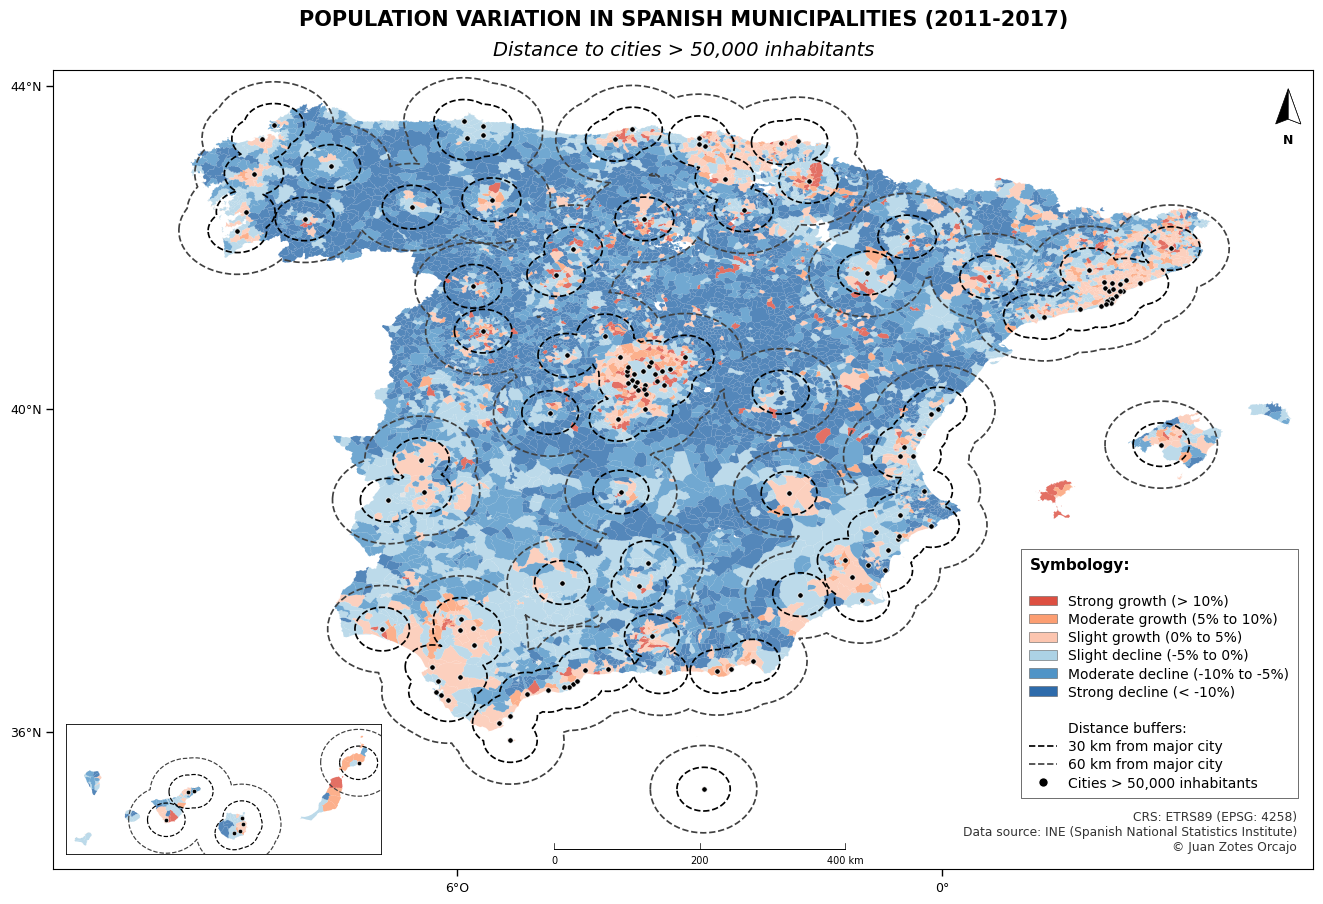

In [12]:
create_population_map(
    gdf_map=gdf_map_2011_2017,
    gdf_cities_pen=gdf_cities_pen_2017,
    gdf_cities_can=gdf_cities_can_2017,
    buffers=buffers_2017,
    period_name='2011-2017',
    output_path=OUTPUT_DIR / 'map_2011_2017_population_variation.png',
    author_name="Juan Zotes Orcajo"
)

✓ Saved: map_2018_2021_population_variation.png


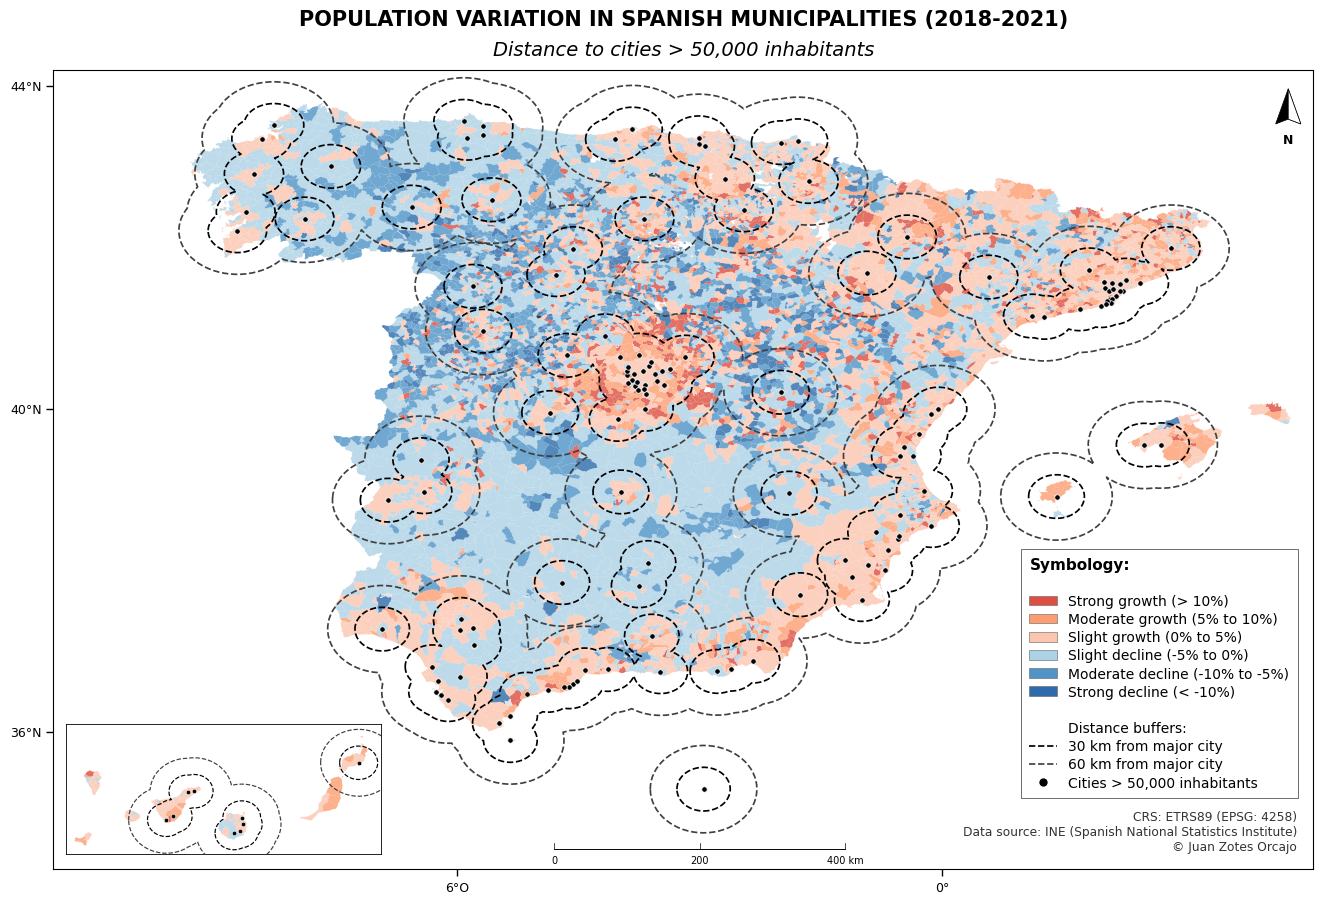

In [13]:
create_population_map(
    gdf_map=gdf_map_2018_2021,
    gdf_cities_pen=gdf_cities_pen_2021,
    gdf_cities_can=gdf_cities_can_2021,
    buffers=buffers_2021,
    period_name='2018-2021',
    output_path=OUTPUT_DIR / 'map_2018_2021_population_variation.png',
    author_name="Juan Zotes Orcajo"
)

✓ Saved: map_2021_2024_population_variation.png


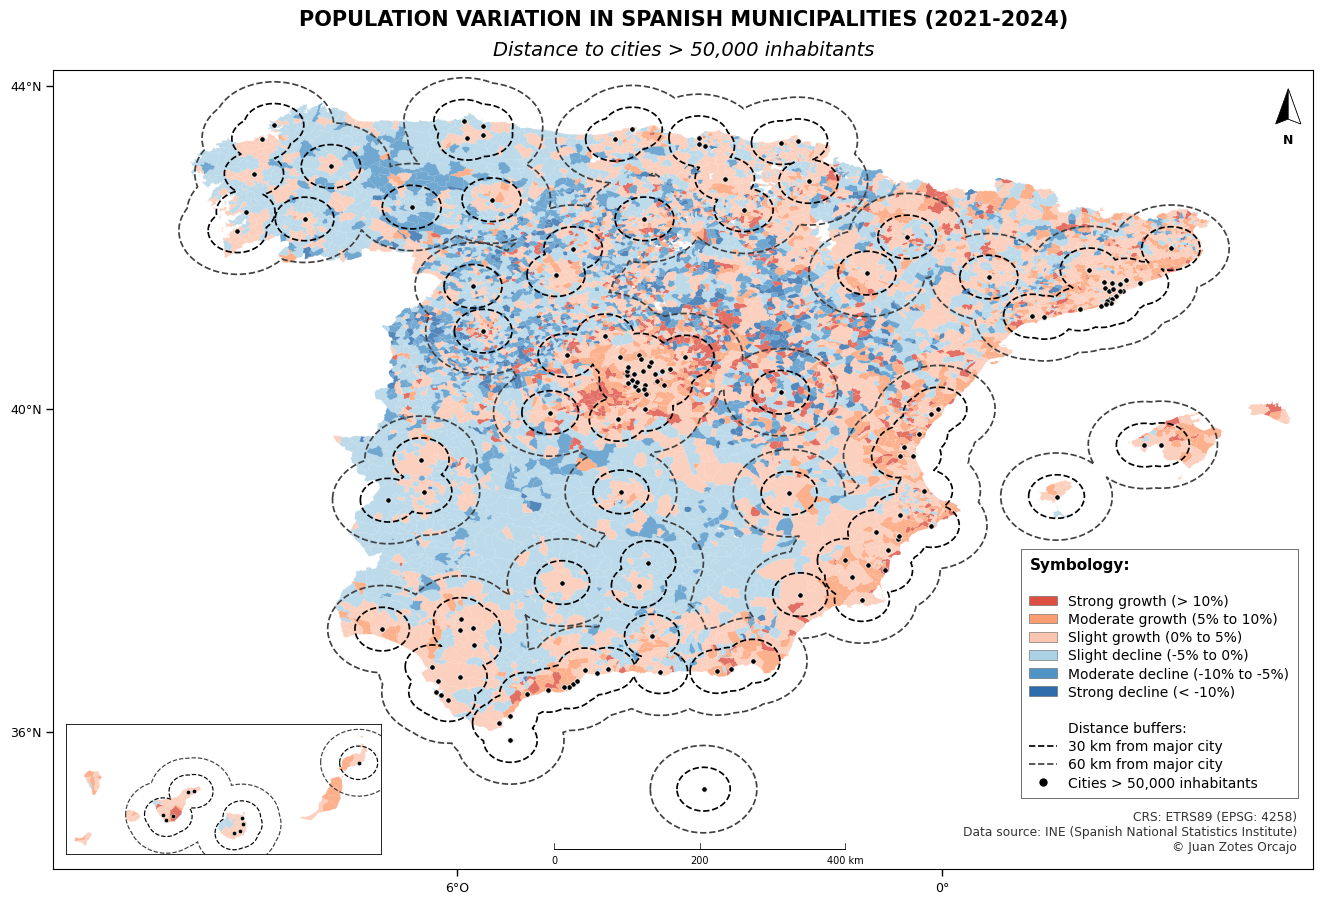

In [14]:
create_population_map(
    gdf_map=gdf_map_2021_2024,
    gdf_cities_pen=gdf_cities_pen_2024,
    gdf_cities_can=gdf_cities_can_2024,
    buffers=buffers_2024,
    period_name='2021-2024',
    output_path=OUTPUT_DIR / 'map_2021_2024_population_variation.png',
    author_name="Juan Zotes Orcajo"
)

##  9. Calculate Distance from Each Municipality to Nearest Major City

To analyze counter-urbanization patterns, we need to calculate the actual distance from each municipality to the nearest city with >50,000 inhabitants. This allows us to classify municipalities into accessibility categories:
- **≤30 km**: Periurban zone (direct urban influence)
- **30-60 km**: Extended commuting zone  
- **>60 km**: Remote rural areas

According to MITERD (2022) and Herrero-Jáuregui et al. (2023), proximity to cities (up to 1 hour) is a key factor explaining counter-urbanization trends since 2018.

In [15]:
# 9.1 Calculate distances

def calculate_distance_to_nearest_city(gdf_municipalities, gdf_cities, crs_projected):
    """
    Calculate minimum distance from each municipality centroid to nearest major city.
    
    Parameters:
    -----------
    gdf_municipalities : GeoDataFrame - All municipalities
    gdf_cities : GeoDataFrame - Cities >50,000 inhabitants (with centroid geometry)
    crs_projected : str - Projected CRS for distance calculation in meters
    
    Returns:
    --------
    pd.Series with distance in km for each municipality
    """
    # Project to UTM for accurate distance calculation
    gdf_mun_proj = gdf_municipalities.to_crs(crs_projected)
    gdf_cities_proj = gdf_cities.to_crs(crs_projected)
    
    # Get centroids of municipalities
    mun_centroids = gdf_mun_proj.geometry.centroid
    
    # Calculate minimum distance to any city for each municipality
    distances_km = []
    for mun_centroid in mun_centroids:
        min_distance = gdf_cities_proj.geometry.distance(mun_centroid).min()
        distances_km.append(min_distance / 1000)  # Convert meters to km
    
    return pd.Series(distances_km, index=gdf_municipalities.index)

# Separate peninsula and Canarias for distance calculation
gdf_pen_for_dist = gdf_mun[~gdf_mun['Mun_Code'].str[:2].isin(CANARIAS_CODES)].copy()
gdf_can_for_dist = gdf_mun[gdf_mun['Mun_Code'].str[:2].isin(CANARIAS_CODES)].copy()

print("Calculating distances to nearest major city (>50,000 inhabitants)...")

# Calculate for Peninsula (using 2024 cities as reference - most current)
distances_peninsula = calculate_distance_to_nearest_city(
    gdf_pen_for_dist, 
    gdf_cities_pen_2024, 
    CRS_PENINSULA
)

# Calculate for Canarias
if len(gdf_cities_can_2024) > 0:
    distances_canarias = calculate_distance_to_nearest_city(
        gdf_can_for_dist,
        gdf_cities_can_2024,
        CRS_CANARIAS
    )
else:
    # If no cities >50k in Canarias in dataset, set as NaN
    distances_canarias = pd.Series([np.nan] * len(gdf_can_for_dist), index=gdf_can_for_dist.index)

# Add distances to main geodataframe
gdf_mun['distance_to_city_km'] = np.nan
gdf_mun.loc[gdf_pen_for_dist.index, 'distance_to_city_km'] = distances_peninsula.values
gdf_mun.loc[gdf_can_for_dist.index, 'distance_to_city_km'] = distances_canarias.values

# Classify by distance buffer
def classify_distance_buffer(dist_km):
    if pd.isna(dist_km):
        return 'Unknown'
    elif dist_km <= 30:
        return '≤30 km'
    elif dist_km <= 60:
        return '30-60 km'
    else:
        return '>60 km'

gdf_mun['distance_class'] = gdf_mun['distance_to_city_km'].apply(classify_distance_buffer)

print(f"✓ Distances calculated for {len(gdf_mun):,} municipalities\n")
print("Distance distribution:")
print(gdf_mun['distance_class'].value_counts())


Calculating distances to nearest major city (>50,000 inhabitants)...


✓ Distances calculated for 8,132 municipalities

Distance distribution:
distance_class
≤30 km      3328
30-60 km    3121
>60 km      1683
Name: count, dtype: int64


## 10. Build Complete Municipal Classification Dataset

Creating a comprehensive dataset with:
- Administrative hierarchy (Municipality, Comarca, Province, CCAA)
- Population (2024)
- Distance to nearest major city
- Population variation for all three periods (2011-2017, 2018-2021, 2021-2024)

Following the population categories from MITERD (2022) and Pujadas-Rubies (2019):
- **<1,000**: Very small rural municipalities
- **1,000-5,000**: Small rural municipalities  
- **5,000-20,000**: Semi-urban municipalities
- **20,000-50,000**: Intermediate municipalities
- **>50,000**: Urban municipalities (major cities)

In [16]:
# 10.1 Get population 2024 and classify

# Merge population 2024
pop_2024 = df_padron_wide[['Mun_Code', 'pop_2024']].copy()
gdf_mun = gdf_mun.merge(pop_2024, on='Mun_Code', how='left')

# Classify municipalities by population size
def classify_municipality_size(pop):
    if pd.isna(pop):
        return 'Unknown'
    elif pop < 1000:
        return '<1,000 (very small rural)'
    elif pop < 5000:
        return '1,000-5,000 (small rural)'
    elif pop < 20000:
        return '5,000-20,000 (semi-urban)'
    elif pop < 50000:
        return '20,000-50,000 (intermediate)'
    else:
        return '>50,000 (urban)'

gdf_mun['municipality_size'] = gdf_mun['pop_2024'].apply(classify_municipality_size)

print("Municipality size distribution (2024 population):")
print(gdf_mun['municipality_size'].value_counts().sort_index())

Municipality size distribution (2024 population):
municipality_size
1,000-5,000 (small rural)       1829
20,000-50,000 (intermediate)     277
5,000-20,000 (semi-urban)        893
<1,000 (very small rural)       4981
>50,000 (urban)                  152
Name: count, dtype: int64


In [17]:
# 10.2 Build export dataframe with all data

# Check available columns in gdf_mun
print("Available columns in gdf_mun:")
print(gdf_mun.columns.tolist())

Available columns in gdf_mun:
['Mun_Code', 'Mun_Name', 'Comarca_Code', 'Comarca_Name', 'Prov_Code', 'Prov_Name', 'CCAA_Code', 'CCAA_Name', 'NATCODE', 'geometry', 'distance_to_city_km', 'distance_class', 'pop_2024', 'municipality_size']


In [18]:
# CODE CELL - 10.3 Create final export dataset

# Build the analysis dataframe
# Note: Adjust column names based on actual column names in your GeoPackage

# First, let's identify the correct column names for administrative hierarchy
admin_cols = [col for col in gdf_mun.columns if any(x in col.lower() for x in ['comarca', 'prov', 'ccaa', 'name', 'mun'])]
print("Potential administrative columns:", admin_cols)

# Create base dataframe (adjust column names as needed based on your GeoPackage)
df_analysis = gdf_mun[['Mun_Code', 'pop_2024', 'distance_to_city_km', 'distance_class', 'municipality_size']].copy()

# Try to add administrative hierarchy columns (adjust names based on your data)
for col in ['Mun_Name', 'Comarca_Name', 'Prov_Name', 'CCAA_Name']:
    if col in gdf_mun.columns:
        df_analysis[col] = gdf_mun[col]

# Add variation data for all three periods
df_analysis = df_analysis.merge(
    period_data['2011-2017'][['Mun_Code', 'var_pct']].rename(columns={'var_pct': 'var_2011_2017'}),
    on='Mun_Code', how='left'
)
df_analysis = df_analysis.merge(
    period_data['2018-2021'][['Mun_Code', 'var_pct']].rename(columns={'var_pct': 'var_2018_2021'}),
    on='Mun_Code', how='left'
)
df_analysis = df_analysis.merge(
    period_data['2021-2024'][['Mun_Code', 'var_pct']].rename(columns={'var_pct': 'var_2021_2024'}),
    on='Mun_Code', how='left'
)

# Sort by population (smallest first)
df_analysis = df_analysis.sort_values('pop_2024', ascending=True)

print(f"✓ Analysis dataset created: {len(df_analysis):,} municipalities")
print(f"\nColumns: {df_analysis.columns.tolist()}")
print(f"\nFirst 10 rows (smallest municipalities):")
df_analysis.head(10)

Potential administrative columns: ['Mun_Code', 'Mun_Name', 'Comarca_Code', 'Comarca_Name', 'Prov_Code', 'Prov_Name', 'CCAA_Code', 'CCAA_Name', 'municipality_size']
✓ Analysis dataset created: 8,132 municipalities

Columns: ['Mun_Code', 'pop_2024', 'distance_to_city_km', 'distance_class', 'municipality_size', 'Mun_Name', 'Comarca_Name', 'Prov_Name', 'CCAA_Name', 'var_2011_2017', 'var_2018_2021', 'var_2021_2024']

First 10 rows (smallest municipalities):


,Mun_Code,pop_2024,distance_to_city_km,distance_class,municipality_size,Mun_Name,Comarca_Name,Prov_Name,CCAA_Name,var_2011_2017,var_2018_2021,var_2021_2024
4220,45080,2.0,25.159099,≤30 km,"<1,000 (very small rural)",Illán de Vacas,TALAVERA,Toledo,Castilla-La Mancha,0.000000,-40.000000,-33.333333
7412,26173,4.0,48.920090,30-60 km,"<1,000 (very small rural)",Villarroya,RIOJA BAJA,La Rioja,La Rioja,-44.444444,0.000000,-20.000000
7339,26154,7.0,19.729191,≤30 km,"<1,000 (very small rural)",Torremontalbo,RIOJA ALTA,La Rioja,La Rioja,-14.285714,10.000000,-36.363636
3830,19031,7.0,54.437824,30-60 km,"<1,000 (very small rural)",Angón,SIERRA,Guadalajara,Castilla-La Mancha,-35.000000,-20.000000,-12.500000
2947,42157,8.0,85.319544,>60 km,"<1,000 (very small rural)",La Riba de Escalote,ALMAZAN,Soria,Castilla y León,-38.888889,22.222222,-27.272727
4121,19310,8.0,66.185250,>60 km,"<1,000 (very small rural)",Valtablado del Río,ALCARRIA BAJA,Guadalajara,Castilla-La Mancha,-30.769231,0.000000,0.000000
4101,19284,8.0,62.312747,>60 km,"<1,000 (very small rural)",Torremochuela,MOLINA DE ARAGON,Guadalajara,Castilla-La Mancha,-8.333333,-27.272727,0.000000
3941,19079,8.0,66.986359,>60 km,"<1,000 (very small rural)",Castilnuevo,MOLINA DE ARAGON,Guadalajara,Castilla-La Mancha,-18.181818,-33.333333,33.333333
2989,42206,8.0,92.233220,>60 km,"<1,000 (very small rural)",Villanueva de Gormaz,BURGO DE OSMA,Soria,Castilla y León,-22.222222,0.000000,0.000000
7325,26153,8.0,24.951839,≤30 km,"<1,000 (very small rural)",Torre en Cameros,SIERRA RIOJA MEDIA,La Rioja,La Rioja,-16.666667,0.000000,-20.000000


In [19]:
# CODE CELL - 10.4 Rename columns and export to CSV

# Rename columns for clarity
df_export = df_analysis.rename(columns={
    'Mun_Name': 'Municipality',
    'pop_2024': 'Population_2024',
    'distance_to_city_km': 'Distance_to_50k_city_km',
    'distance_class': 'Distance_class',
    'municipality_size': 'Municipality_size',
    'var_2011_2017': 'Var_2011_2017_pct',
    'var_2018_2021': 'Var_2018_2021_pct', 
    'var_2021_2024': 'Var_2021_2024_pct',
    'Comarca_Name': 'Comarca',
    'Prov_Name': 'Province',
    'CCAA_Name': 'CCAA'
})

# Reorder columns
cols_order = ['Mun_Code', 'Municipality', 'Population_2024', 'Distance_to_50k_city_km', 
              'Distance_class', 'Var_2011_2017_pct', 'Var_2018_2021_pct', 'Var_2021_2024_pct',
              'Municipality_size', 'Comarca', 'Province', 'CCAA']
# Keep only columns that exist
cols_order = [c for c in cols_order if c in df_export.columns]
df_export = df_export[cols_order]

# Export to CSV
output_csv_path = VARIATIONS_DIR / "municipalities_population_dynamics_classification.csv"
df_export.to_csv(output_csv_path, index=False, encoding='utf-8')

print(f"✓ Exported to: {output_csv_path}")
print(f"\nDataset preview:")
df_export.head(10)

✓ Exported to: /workspaces/rural-migration-land-use-spain/data/demography/derived/municipalities_population_dynamics_classification.csv

Dataset preview:


,Mun_Code,Municipality,Population_2024,Distance_to_50k_city_km,Distance_class,Var_2011_2017_pct,Var_2018_2021_pct,Var_2021_2024_pct,Municipality_size,Comarca,Province,CCAA
4220,45080,Illán de Vacas,2.0,25.159099,≤30 km,0.000000,-40.000000,-33.333333,"<1,000 (very small rural)",TALAVERA,Toledo,Castilla-La Mancha
7412,26173,Villarroya,4.0,48.920090,30-60 km,-44.444444,0.000000,-20.000000,"<1,000 (very small rural)",RIOJA BAJA,La Rioja,La Rioja
7339,26154,Torremontalbo,7.0,19.729191,≤30 km,-14.285714,10.000000,-36.363636,"<1,000 (very small rural)",RIOJA ALTA,La Rioja,La Rioja
3830,19031,Angón,7.0,54.437824,30-60 km,-35.000000,-20.000000,-12.500000,"<1,000 (very small rural)",SIERRA,Guadalajara,Castilla-La Mancha
2947,42157,La Riba de Escalote,8.0,85.319544,>60 km,-38.888889,22.222222,-27.272727,"<1,000 (very small rural)",ALMAZAN,Soria,Castilla y León
4121,19310,Valtablado del Río,8.0,66.185250,>60 km,-30.769231,0.000000,0.000000,"<1,000 (very small rural)",ALCARRIA BAJA,Guadalajara,Castilla-La Mancha
4101,19284,Torremochuela,8.0,62.312747,>60 km,-8.333333,-27.272727,0.000000,"<1,000 (very small rural)",MOLINA DE ARAGON,Guadalajara,Castilla-La Mancha
3941,19079,Castilnuevo,8.0,66.986359,>60 km,-18.181818,-33.333333,33.333333,"<1,000 (very small rural)",MOLINA DE ARAGON,Guadalajara,Castilla-La Mancha
2989,42206,Villanueva de Gormaz,8.0,92.233220,>60 km,-22.222222,0.000000,0.000000,"<1,000 (very small rural)",BURGO DE OSMA,Soria,Castilla y León
7325,26153,Torre en Cameros,8.0,24.951839,≤30 km,-16.666667,0.000000,-20.000000,"<1,000 (very small rural)",SIERRA RIOJA MEDIA,La Rioja,La Rioja


## 11. Analysis of Demographic Dynamics by Municipality Type and Period

Based on key findings from the literature:

**MITERD (2022) - Key turning point in 2018:**
- 2011-2017: Rural exodus - small municipalities lost 136,131 inhabitants
- 2018-2021: Trend reversal - small municipalities (<5,000) gained 115,805 inhabitants
- COVID-19 pandemic accelerated but did not initiate this counter-urbanization

**Herrero-Jáuregui et al. (2023) - Counter-urbanization factors:**
- Proximity to cities (up to 1 hour drive) is crucial
- Digital connectivity enables remote work
- Mediterranean countries show distinct patterns vs. Anglo-Saxon countries

**Pujadas-Rubies & Bayona-i-Carrasco (2019):**
- 60% of Spanish municipalities have <1,000 inhabitants
- Different dynamics in very small (<1,000) vs small (1,000-5,000) municipalities

In [20]:
# CODE CELL - 11.1 Summary statistics by period and municipality size
# =============================================================================
print("=" * 90)
print("POPULATION DYNAMICS BY MUNICIPALITY SIZE AND PERIOD")
print("=" * 90)

size_order = ['<1,000 (very small rural)', '1,000-5,000 (small rural)', 
              '5,000-20,000 (semi-urban)', '20,000-50,000 (intermediate)', '>50,000 (urban)']

for size_cat in size_order:
    subset = df_export[df_export['Municipality_size'] == size_cat]
    n_mun = len(subset)
    
    print(f"\n{'='*70}")
    print(f"{size_cat.upper()}: {n_mun:,} municipalities")
    print(f"{'='*70}")
    
    for period, col in [('2011-2017', 'Var_2011_2017_pct'), 
                        ('2018-2021', 'Var_2018_2021_pct'),
                        ('2021-2024', 'Var_2021_2024_pct')]:
        growing = (subset[col] > 0).sum()
        declining = (subset[col] < 0).sum()
        stable = (subset[col] == 0).sum()
        pct_growing = growing / n_mun * 100 if n_mun > 0 else 0
        mean_var = subset[col].mean()
        
        print(f"  {period}: {growing:,} growing ({pct_growing:.1f}%), {declining:,} declining, mean: {mean_var:+.2f}%")

POPULATION DYNAMICS BY MUNICIPALITY SIZE AND PERIOD

<1,000 (VERY SMALL RURAL): 4,981 municipalities
  2011-2017: 553 growing (11.1%), 4,366 declining, mean: -11.37%
  2018-2021: 1,854 growing (37.2%), 2,966 declining, mean: -0.96%
  2021-2024: 2,140 growing (43.0%), 2,663 declining, mean: +0.10%

1,000-5,000 (SMALL RURAL): 1,829 municipalities
  2011-2017: 404 growing (22.1%), 1,410 declining, mean: -4.73%
  2018-2021: 955 growing (52.2%), 862 declining, mean: +0.92%
  2021-2024: 1,036 growing (56.6%), 780 declining, mean: +1.38%

5,000-20,000 (SEMI-URBAN): 893 municipalities
  2011-2017: 375 growing (42.0%), 517 declining, mean: -0.50%
  2018-2021: 608 growing (68.1%), 284 declining, mean: +2.02%
  2021-2024: 654 growing (73.2%), 238 declining, mean: +2.58%

20,000-50,000 (INTERMEDIATE): 277 municipalities
  2011-2017: 135 growing (48.7%), 142 declining, mean: +0.65%
  2018-2021: 232 growing (83.8%), 45 declining, mean: +2.39%
  2021-2024: 241 growing (87.0%), 36 declining, mean: +3.

In [21]:
# CODE CELL - 11.2 Summary by distance to major cities
# =============================================================================
print("\n" + "=" * 90)
print("POPULATION DYNAMICS BY DISTANCE TO MAJOR CITY (>50,000 inhabitants)")
print("=" * 90)

for dist_cat in ['≤30 km', '30-60 km', '>60 km']:
    subset = df_export[df_export['Distance_class'] == dist_cat]
    n_mun = len(subset)
    
    print(f"\n{'='*70}")
    print(f"DISTANCE: {dist_cat} - {n_mun:,} municipalities")
    print(f"{'='*70}")
    
    for period, col in [('2011-2017', 'Var_2011_2017_pct'), 
                        ('2018-2021', 'Var_2018_2021_pct'),
                        ('2021-2024', 'Var_2021_2024_pct')]:
        growing = (subset[col] > 0).sum()
        pct_growing = growing / n_mun * 100 if n_mun > 0 else 0
        mean_var = subset[col].mean()
        
        print(f"  {period}: {growing:,} growing ({pct_growing:.1f}%), mean variation: {mean_var:+.2f}%")


POPULATION DYNAMICS BY DISTANCE TO MAJOR CITY (>50,000 inhabitants)

DISTANCE: ≤30 km - 3,328 municipalities
  2011-2017: 1,144 growing (34.4%), mean variation: -3.59%
  2018-2021: 2,118 growing (63.6%), mean variation: +1.84%
  2021-2024: 2,247 growing (67.5%), mean variation: +2.44%

DISTANCE: 30-60 km - 3,121 municipalities
  2011-2017: 273 growing (8.7%), mean variation: -10.88%
  2018-2021: 1,107 growing (35.5%), mean variation: -1.34%
  2021-2024: 1,332 growing (42.7%), mean variation: -0.07%

DISTANCE: >60 km - 1,683 municipalities
  2011-2017: 123 growing (7.3%), mean variation: -11.65%
  2018-2021: 533 growing (31.7%), mean variation: -1.41%
  2021-2024: 627 growing (37.3%), mean variation: -0.76%


## 12. Identifying Municipalities with Population Growth by Category

Now we identify specific municipalities that have experienced population growth, categorized by:
1. Municipality size (rural < 5,000, semi-urban 5,000-20,000, etc.)
2. Distance to major cities (periurban ≤30km, extended 30-60km, remote >60km)
3. Time period (pre-2018 decline period vs post-2018 recovery)

This allows us to identify specific examples of counter-urbanization patterns described in the literature.

In [22]:
# CODE CELL - 12.1 Rural municipalities (<5,000) with growth - by period

print("=" * 90)
print("RURAL MUNICIPALITIES (<5,000 inhabitants) WITH POPULATION GROWTH")
print("=" * 90)

rural = df_export[df_export['Population_2024'] < 5000]
total_rural = len(rural)

# Period 2011-2017 (before trend reversal)
rural_growth_2011_2017 = rural[rural['Var_2011_2017_pct'] > 0].sort_values(
    'Var_2011_2017_pct', ascending=False
)
print(
    f"\n2011-2017 (pre-reversal): {len(rural_growth_2011_2017):,} rural municipalities with growth "
    f"({len(rural_growth_2011_2017) / total_rural * 100:.1f}%)"
)

# Period 2018-2021 (post trend reversal, including COVID)
rural_growth_2018_2021 = rural[rural['Var_2018_2021_pct'] > 0].sort_values(
    'Var_2018_2021_pct', ascending=False
)
print(
    f"2018-2021 (post-reversal): {len(rural_growth_2018_2021):,} rural municipalities with growth "
    f"({len(rural_growth_2018_2021) / total_rural * 100:.1f}%)"
)

# Period 2021-2024 (post-COVID consolidation)
rural_growth_2021_2024 = rural[rural['Var_2021_2024_pct'] > 0].sort_values(
    'Var_2021_2024_pct', ascending=False
)
print(
    f"2021-2024 (consolidation): {len(rural_growth_2021_2024):,} rural municipalities with growth "
    f"({len(rural_growth_2021_2024) / total_rural * 100:.1f}%)"
)

# Change from 2011-2017 to 2018-2021
change = len(rural_growth_2018_2021) - len(rural_growth_2011_2017)
print(
    f"\n→ Change in number of growing rural municipalities: {change:+,} "
    f"({change / len(rural_growth_2011_2017) * 100:+.1f}%)"
)

RURAL MUNICIPALITIES (<5,000 inhabitants) WITH POPULATION GROWTH

2011-2017 (pre-reversal): 957 rural municipalities with growth (14.1%)
2018-2021 (post-reversal): 2,809 rural municipalities with growth (41.2%)
2021-2024 (consolidation): 3,176 rural municipalities with growth (46.6%)

→ Change in number of growing rural municipalities: +1,852 (+193.5%)


In [23]:
# CODE CELL - 12.2 Rural growth by distance class - detailed

print("\n" + "=" * 90)
print("RURAL MUNICIPALITIES (<5,000) WITH GROWTH - BY DISTANCE TO MAJOR CITY")
print("=" * 90)

for period, col in [('2011-2017', 'Var_2011_2017_pct'), 
                    ('2018-2021', 'Var_2018_2021_pct'),
                    ('2021-2024', 'Var_2021_2024_pct')]:
    print(f"\n--- {period} ---")
    
    for dist_class in ['≤30 km', '30-60 km', '>60 km']:
        subset = rural[(rural['Distance_class'] == dist_class)]
        total = len(subset)
        growing = (subset[col] > 0).sum()
        pct = growing / total * 100 if total > 0 else 0
        mean_var = subset[col].mean()
        
        print(f"  {dist_class}: {growing:,}/{total:,} growing ({pct:.1f}%), mean: {mean_var:+.2f}%")


RURAL MUNICIPALITIES (<5,000) WITH GROWTH - BY DISTANCE TO MAJOR CITY

--- 2011-2017 ---
  ≤30 km: 611/2,365 growing (25.8%), mean: -5.56%
  30-60 km: 231/2,859 growing (8.1%), mean: -11.53%
  >60 km: 115/1,586 growing (7.3%), mean: -12.09%

--- 2018-2021 ---
  ≤30 km: 1,342/2,365 growing (56.7%), mean: +1.52%
  30-60 km: 981/2,859 growing (34.3%), mean: -1.50%
  >60 km: 486/1,586 growing (30.6%), mean: -1.53%

--- 2021-2024 ---
  ≤30 km: 1,425/2,365 growing (60.3%), mean: +2.08%
  30-60 km: 1,188/2,859 growing (41.6%), mean: -0.16%
  >60 km: 563/1,586 growing (35.5%), mean: -0.91%


In [24]:
# CODE CELL - 12.3 Top growing rural municipalities - PERIURBAN (≤30 km)

print("\n" + "=" * 90)
print("TOP 15 GROWING RURAL MUNICIPALITIES - PERIURBAN ZONE (≤30 km from major city)")
print("Period: 2018-2021 (post-trend reversal)")
print("=" * 90)

periurban_rural_growth = rural[
    (rural['Distance_class'] == '≤30 km') & 
    (rural['Var_2018_2021_pct'] > 0)
].sort_values('Var_2018_2021_pct', ascending=False)

display_cols = ['Municipality', 'Province', 'CCAA', 'Population_2024', 
                'Distance_to_50k_city_km', 'Var_2018_2021_pct']
display_cols = [c for c in display_cols if c in periurban_rural_growth.columns]

print(f"\nTotal: {len(periurban_rural_growth):,} periurban rural municipalities with growth")
periurban_rural_growth[display_cols].head(15)



TOP 15 GROWING RURAL MUNICIPALITIES - PERIURBAN ZONE (≤30 km from major city)
Period: 2018-2021 (post-trend reversal)

Total: 1,342 periurban rural municipalities with growth


,Municipality,Province,CCAA,Population_2024,Distance_to_50k_city_km,Var_2018_2021_pct
7398,Sojuela,La Rioja,La Rioja,659.0,14.419254,57.094595
5421,Villamalur,Castelló/Castellón,Comunitat Valenciana,97.0,23.950625,46.031746
3938,Caspueñas,Guadalajara,Castilla-La Mancha,133.0,18.293601,39.759036
1948,Villaldemiro,Burgos,Castilla y León,91.0,27.589727,39.436620
12,Reinoso,Burgos,Castilla y León,18.0,29.851683,36.363636
5837,El Carrascalejo,Badajoz,Extremadura,77.0,8.480687,34.328358
3795,Centenera,Guadalajara,Castilla-La Mancha,140.0,10.048503,33.644860
4099,Viñuelas,Guadalajara,Castilla-La Mancha,183.0,22.230314,32.846715
7321,Daroca de Rioja,La Rioja,La Rioja,66.0,16.329408,31.914894
7295,Bezares,La Rioja,La Rioja,21.0,20.921188,31.578947


In [25]:
# CODE CELL - 12.4 Top growing rural municipalities - EXTENDED ZONE (30-60 km)

print("\n" + "=" * 90)
print("TOP 15 GROWING RURAL MUNICIPALITIES - EXTENDED ZONE (30-60 km from major city)")
print("Period: 2018-2021")
print("=" * 90)

extended_rural_growth = rural[
    (rural['Distance_class'] == '30-60 km') & 
    (rural['Var_2018_2021_pct'] > 0)
].sort_values('Var_2018_2021_pct', ascending=False)

print(f"\nTotal: {len(extended_rural_growth):,} extended-zone rural municipalities with growth")
extended_rural_growth[display_cols].head(15)


TOP 15 GROWING RURAL MUNICIPALITIES - EXTENDED ZONE (30-60 km from major city)
Period: 2018-2021

Total: 981 extended-zone rural municipalities with growth


,Municipality,Province,CCAA,Population_2024,Distance_to_50k_city_km,Var_2018_2021_pct
7539,Grisaleña,Burgos,Castilla y León,53.0,43.371092,75.675676
3723,Huelves,Cuenca,Castilla-La Mancha,88.0,53.567935,64.705882
3962,Fuembellida,Guadalajara,Castilla-La Mancha,14.0,59.503690,62.500000
7332,Galbárruli,La Rioja,La Rioja,79.0,33.537306,56.000000
4131,Zarzuela de Jadraque,Guadalajara,Castilla-La Mancha,52.0,47.897316,51.351351
2554,Estepa de San Juan,Soria,Castilla y León,13.0,59.231882,50.000000
6650,La Hiruela,Madrid,Comunidad de Madrid,83.0,51.253646,50.000000
6712,Robregordo,Madrid,Comunidad de Madrid,73.0,52.287011,47.916667
4061,Villanueva de Argecilla,Guadalajara,Castilla-La Mancha,32.0,36.490589,37.931034
1713,Navaquesera,Ávila,Castilla y León,43.0,35.138669,37.500000


In [26]:
# CODE CELL - 12.5 Top growing rural municipalities - REMOTE (>60 km)
# =============================================================================
print("\n" + "=" * 90)
print("TOP 15 GROWING RURAL MUNICIPALITIES - REMOTE AREAS (>60 km from major city)")
print("Period: 2018-2021")
print("These are particularly interesting - growth despite distance (amenity migration?)")
print("=" * 90)

remote_rural_growth = rural[
    (rural['Distance_class'] == '>60 km') & 
    (rural['Var_2018_2021_pct'] > 0)
].sort_values('Var_2018_2021_pct', ascending=False)

print(f"\nTotal: {len(remote_rural_growth):,} remote rural municipalities with growth")
remote_rural_growth[display_cols].head(15)


TOP 15 GROWING RURAL MUNICIPALITIES - REMOTE AREAS (>60 km from major city)
Period: 2018-2021
These are particularly interesting - growth despite distance (amenity migration?)

Total: 486 remote rural municipalities with growth


,Municipality,Province,CCAA,Population_2024,Distance_to_50k_city_km,Var_2018_2021_pct
2851,Arenillas,Soria,Castilla y León,42.0,82.707637,95.833333
7454,La Zoma,Teruel,Aragón,27.0,99.342796,93.750000
7563,Valle de Bardají,Huesca,Aragón,55.0,80.964384,88.235294
2760,Pajarejos,Segovia,Castilla y León,24.0,72.584950,75.000000
3861,La Olmeda de Jadraque,Guadalajara,Castilla-La Mancha,19.0,64.982848,66.666667
2585,Castro de Fuentidueña,Segovia,Castilla y León,48.0,63.084303,62.068966
4085,Tierzo,Guadalajara,Castilla-La Mancha,34.0,60.570723,60.000000
7501,Cabolafuente,Zaragoza,Aragón,50.0,106.368203,53.125000
947,Campo,Huesca,Aragón,483.0,75.865874,42.105263
6081,Gargüera,Cáceres,Extremadura,182.0,85.591585,39.062500


In [27]:
# CODE CELL - 12.6 Semi-urban municipalities (5,000-20,000) with growth

print("\n" + "=" * 90)
print("SEMI-URBAN MUNICIPALITIES (5,000-20,000 inhabitants) WITH GROWTH")
print("These often act as service centers for surrounding rural areas")
print("=" * 90)

semi_urban = df_export[
    (df_export['Population_2024'] >= 5000) & 
    (df_export['Population_2024'] < 20000)
]

for period, col in [('2011-2017', 'Var_2011_2017_pct'), 
                    ('2018-2021', 'Var_2018_2021_pct'),
                    ('2021-2024', 'Var_2021_2024_pct')]:
    print(f"\n--- {period} ---")
    for dist_class in ['≤30 km', '30-60 km', '>60 km']:
        subset = semi_urban[semi_urban['Distance_class'] == dist_class]
        total = len(subset)
        growing = (subset[col] > 0).sum()
        pct = growing / total * 100 if total > 0 else 0
        print(f"  {dist_class}: {growing:,}/{total:,} growing ({pct:.1f}%)")


SEMI-URBAN MUNICIPALITIES (5,000-20,000 inhabitants) WITH GROWTH
These often act as service centers for surrounding rural areas

--- 2011-2017 ---
  ≤30 km: 337/597 growing (56.4%)
  30-60 km: 32/217 growing (14.7%)
  >60 km: 6/79 growing (7.6%)

--- 2018-2021 ---
  ≤30 km: 477/597 growing (79.9%)
  30-60 km: 97/217 growing (44.7%)
  >60 km: 34/79 growing (43.0%)

--- 2021-2024 ---
  ≤30 km: 493/597 growing (82.6%)
  30-60 km: 114/217 growing (52.5%)
  >60 km: 47/79 growing (59.5%)


In [28]:
# CODE CELL - 12.7 Top growing semi-urban municipalities

print("\n" + "=" * 90)
print("TOP 10 GROWING SEMI-URBAN MUNICIPALITIES (5,000-20,000) - 2018-2021")
print("=" * 90)

semi_urban_growth = semi_urban[
    semi_urban['Var_2018_2021_pct'] > 0
].sort_values('Var_2018_2021_pct', ascending=False)

semi_urban_growth[display_cols].head(10)


TOP 10 GROWING SEMI-URBAN MUNICIPALITIES (5,000-20,000) - 2018-2021


,Municipality,Province,CCAA,Population_2024,Distance_to_50k_city_km,Var_2018_2021_pct
4128,Yebes,Guadalajara,Castilla-La Mancha,5421.0,12.698585,31.779420
7815,Pioz,Guadalajara,Castilla-La Mancha,5204.0,17.037490,24.323607
4384,El Viso de San Juan,Toledo,Castilla-La Mancha,6164.0,20.294287,20.776833
710,Casares,Málaga,Andalucía,8486.0,12.651358,19.947721
4262,Ocaña,Toledo,Castilla-La Mancha,14469.0,15.195548,17.674166
5743,Nàquera/Náquera,València/Valencia,Comunitat Valenciana,8308.0,13.040551,17.663175
7259,Urduliz,Bizkaia,País Vasco/Euskadi,5711.0,5.386709,16.554758
5389,Finestrat,Alacant/Alicante,Comunitat Valenciana,9352.0,6.837960,16.000627
4391,Yuncler,Toledo,Castilla-La Mancha,5033.0,20.203266,15.562650
205,Mojácar,Almería,Andalucía,7517.0,49.950256,15.172195


## 13. Trend Reversal Analysis: From Decline to Growth

Identifying municipalities that experienced:
- **Decline in 2011-2017** (during rural exodus period)
- **Growth in 2018-2021** (during counter-urbanization period)

This confirms the MITERD (2022) finding about 2018 as a turning point in Spanish demographic trends.

In [29]:
# CODE CELL - 13.1 Municipalities that reversed their trend

print("=" * 90)
print("TREND REVERSAL: Municipalities that went from DECLINE to GROWTH")
print("(Declining 2011-2017 → Growing 2018-2021)")
print("=" * 90)

# Rural municipalities with trend reversal
rural_reversal = rural[
    (rural['Var_2011_2017_pct'] < 0) &  # Declining before 2018
    (rural['Var_2018_2021_pct'] > 0)     # Growing after 2018
].copy()

rural_reversal['improvement'] = rural_reversal['Var_2018_2021_pct'] - rural_reversal['Var_2011_2017_pct']
rural_reversal = rural_reversal.sort_values('improvement', ascending=False)

print(f"\nRural municipalities (<5,000) with trend reversal: {len(rural_reversal):,}")
print("\nBy distance class:")
print(rural_reversal['Distance_class'].value_counts())

TREND REVERSAL: Municipalities that went from DECLINE to GROWTH
(Declining 2011-2017 → Growing 2018-2021)

Rural municipalities (<5,000) with trend reversal: 2,112

By distance class:
Distance_class
≤30 km      850
30-60 km    838
>60 km      424
Name: count, dtype: int64


In [30]:
# CODE CELL - 13.2 Top trend reversal examples

print("\n" + "=" * 90)
print("TOP 20 RURAL MUNICIPALITIES WITH STRONGEST TREND REVERSAL")
print("=" * 90)

reversal_cols = ['Municipality', 'Province', 'CCAA', 'Population_2024', 'Distance_class',
                 'Var_2011_2017_pct', 'Var_2018_2021_pct', 'improvement']
reversal_cols = [c for c in reversal_cols if c in rural_reversal.columns]

rural_reversal[reversal_cols].head(20)


TOP 20 RURAL MUNICIPALITIES WITH STRONGEST TREND REVERSAL


,Municipality,Province,CCAA,Population_2024,Distance_class,Var_2011_2017_pct,Var_2018_2021_pct,improvement
3861,La Olmeda de Jadraque,Guadalajara,Castilla-La Mancha,19.0,>60 km,-61.111111,66.666667,127.777778
2760,Pajarejos,Segovia,Castilla y León,24.0,>60 km,-50.000000,75.000000,125.000000
2851,Arenillas,Soria,Castilla y León,42.0,>60 km,-23.529412,95.833333,119.362745
7563,Valle de Bardají,Huesca,Aragón,55.0,>60 km,-30.000000,88.235294,118.235294
3962,Fuembellida,Guadalajara,Castilla-La Mancha,14.0,30-60 km,-50.000000,62.500000,112.500000
7454,La Zoma,Teruel,Aragón,27.0,>60 km,-18.181818,93.750000,111.931818
2585,Castro de Fuentidueña,Segovia,Castilla y León,48.0,>60 km,-43.859649,62.068966,105.928615
3723,Huelves,Cuenca,Castilla-La Mancha,88.0,30-60 km,-29.870130,64.705882,94.576012
2554,Estepa de San Juan,Soria,Castilla y León,13.0,30-60 km,-36.363636,50.000000,86.363636
5421,Villamalur,Castelló/Castellón,Comunitat Valenciana,97.0,≤30 km,-39.215686,46.031746,85.247432


In [31]:
# CODE CELL - 13.3 Check if reversal was sustained through 2024

print("\n" + "=" * 90)
print("SUSTAINED REVERSAL: Did growth continue 2021-2024?")
print("=" * 90)

# Add 2021-2024 data
rural_reversal['Growth_2021_2024'] = rural_reversal['Var_2021_2024_pct'] > 0

sustained = rural_reversal[rural_reversal['Growth_2021_2024'] == True]
not_sustained = rural_reversal[rural_reversal['Growth_2021_2024'] == False]

print(f"\nMunicipalities that sustained growth through 2024: {len(sustained):,}")
print(f"Municipalities that stopped growing: {len(not_sustained):,}")
print(f"Sustainability rate: {len(sustained)/len(rural_reversal)*100:.1f}%")

print("\n" + "=" * 90)
print("COMPARISON TABLE: Decline → Growth → Sustained?")
print("=" * 90)

comparison_cols = ['Municipality', 'Province', 'CCAA', 'Distance_class',
                   'Var_2011_2017_pct', 'Var_2018_2021_pct', 'Var_2021_2024_pct', 
                   'Growth_2021_2024']

print("\nTop 20 with strongest sustained growth:")
sustained_sorted = sustained.sort_values('Var_2021_2024_pct', ascending=False)
sustained_sorted[comparison_cols].head(20)


SUSTAINED REVERSAL: Did growth continue 2021-2024?

Municipalities that sustained growth through 2024: 1,228
Municipalities that stopped growing: 884
Sustainability rate: 58.1%

COMPARISON TABLE: Decline → Growth → Sustained?

Top 20 with strongest sustained growth:


,Municipality,Province,CCAA,Distance_class,Var_2011_2017_pct,Var_2018_2021_pct,Var_2021_2024_pct,Growth_2021_2024
1713,Navaquesera,Ávila,Castilla y León,30-60 km,-40.000000,37.500000,95.454545,True
7322,Torrecilla sobre Alesanco,La Rioja,La Rioja,30-60 km,-10.526316,16.666667,57.142857,True
3851,Copernal,Guadalajara,Castilla-La Mancha,≤30 km,-36.585366,29.166667,48.387097,True
3857,Vindel,Cuenca,Castilla-La Mancha,30-60 km,-44.444444,10.000000,45.454545,True
2554,Estepa de San Juan,Soria,Castilla y León,30-60 km,-36.363636,50.000000,44.444444,True
2974,Ucero,Soria,Castilla y León,>60 km,-32.911392,21.153846,44.444444,True
4062,Robledillo de Mohernando,Guadalajara,Castilla-La Mancha,≤30 km,-9.166667,19.811321,44.094488,True
4127,Villaseca de Uceda,Guadalajara,Castilla-La Mancha,≤30 km,-30.508475,11.111111,42.500000,True
8027,Sisamón,Zaragoza,Aragón,>60 km,-23.255814,6.451613,42.424242,True
3918,Barriopedro,Guadalajara,Castilla-La Mancha,30-60 km,-26.086957,6.250000,41.176471,True


## 14. Regional Analysis: Counter-urbanization by Autonomous Community

Different regions show varying patterns of counter-urbanization. Key areas of interest based on the RURIMESCAPE project:
- **Madrid region**: Sierra Oeste - periurban counter-urbanization
- **Castilla y León / Castilla-La Mancha**: Traditional depopulation areas
- **Coastal areas**: Tourism-driven growth
- **Pyrenees / Mountain areas**: Amenity migration

In [32]:
# CODE CELL - 14.1 Summary by CCAA
print("=" * 90)
print("RURAL MUNICIPALITIES (<5,000) WITH GROWTH BY AUTONOMOUS COMMUNITY")
print("Period: 2018-2021")
print("=" * 90)

if 'CCAA' in rural.columns:
    ccaa_summary = []
    
    for ccaa in rural['CCAA'].dropna().unique():
        ccaa_rural = rural[rural['CCAA'] == ccaa]
        total = len(ccaa_rural)
        growing = (ccaa_rural['Var_2018_2021_pct'] > 0).sum()
        pct = growing / total * 100 if total > 0 else 0
        mean_var = ccaa_rural['Var_2018_2021_pct'].mean()
        
        ccaa_summary.append({
            'CCAA': ccaa,
            'Total_rural_mun': total,
            'Growing_mun': growing,
            'Pct_growing': pct,
            'Mean_variation': mean_var
        })
    
    df_ccaa_summary = pd.DataFrame(ccaa_summary).sort_values('Pct_growing', ascending=False)
    df_ccaa_summary['Pct_growing'] = df_ccaa_summary['Pct_growing'].round(1)
    df_ccaa_summary['Mean_variation'] = df_ccaa_summary['Mean_variation'].round(2)
    
    print(f"\nTotal: {len(rural):,} rural municipalities across {len(df_ccaa_summary)} autonomous communities\n")
    display(df_ccaa_summary)
else:
    print("CCAA column not available in dataset")

RURAL MUNICIPALITIES (<5,000) WITH GROWTH BY AUTONOMOUS COMMUNITY
Period: 2018-2021

Total: 6,810 rural municipalities across 17 autonomous communities



,CCAA,Total_rural_mun,Growing_mun,Pct_growing,Mean_variation
9,Comunidad de Madrid,97,94,96.9,10.45
13,Illes Balears,25,24,96.0,5.60
16,Canarias,26,19,73.1,2.52
11,País Vasco/Euskadi,179,122,68.2,1.37
6,Cataluña/Catalunya,730,497,68.1,2.51
15,Región de Murcia,8,5,62.5,2.83
5,Comunitat Valenciana,382,232,60.7,1.98
7,Cantabria,80,43,53.8,0.42
1,La Rioja,165,84,50.9,2.30
4,Comunidad Foral de Navarra,251,122,48.6,-0.11


In [33]:
# CODE CELL - 14.2 Examples from key regions - Madrid
# =============================================================================
print("\n" + "=" * 90)
print("MADRID REGION - Rural municipalities with growth (2018-2021)")
print("Focus area for RURIMESCAPE project: Sierra Oeste")
print("=" * 90)

if 'CCAA' in rural.columns:
    madrid_rural = rural[rural['CCAA'].str.contains('Madrid', case=False, na=False)]
    madrid_growth = madrid_rural[madrid_rural['Var_2018_2021_pct'] > 0].sort_values('Var_2018_2021_pct', ascending=False)
    
    print(f"\nTotal rural municipalities in Madrid: {len(madrid_rural)}")
    print(f"With growth 2018-2021: {len(madrid_growth)} ({len(madrid_growth)/len(madrid_rural)*100:.1f}%)")
    
    # Display columns
    display_cols = ['Municipality', 'Province', 'Population_2024', 'Distance_to_50k_city_km', 
                    'Distance_class', 'Var_2018_2021_pct', 'Var_2021_2024_pct']
    display_cols = [c for c in display_cols if c in madrid_growth.columns]
    
    if len(madrid_growth) > 0:
        print("\nTop 10 growing rural municipalities in Madrid:")
        display(madrid_growth[display_cols].head(10))
    else:
        print("No growing rural municipalities found in Madrid")
else:
    print("CCAA column not available")


MADRID REGION - Rural municipalities with growth (2018-2021)
Focus area for RURIMESCAPE project: Sierra Oeste

Total rural municipalities in Madrid: 97
With growth 2018-2021: 94 (96.9%)

Top 10 growing rural municipalities in Madrid:


,Municipality,Province,Population_2024,Distance_to_50k_city_km,Distance_class,Var_2018_2021_pct,Var_2021_2024_pct
6650,La Hiruela,Madrid,83.0,51.253646,30-60 km,50.000000,15.277778
6712,Robregordo,Madrid,73.0,52.287011,30-60 km,47.916667,2.816901
6680,La Serna del Monte,Madrid,105.0,42.746745,30-60 km,29.729730,9.375000
6702,Prádena del Rincón,Madrid,139.0,46.227886,30-60 km,27.350427,-6.711409
6514,Alameda del Valle,Madrid,255.0,26.929291,≤30 km,26.153846,3.658537
6703,Puebla de la Sierra,Madrid,93.0,45.142354,30-60 km,25.000000,24.000000
6708,Ribatejada,Madrid,900.0,18.649045,≤30 km,22.237960,4.287370
6721,Santa María de la Alameda,Madrid,1517.0,22.332986,≤30 km,21.489002,5.640669
6661,Madarcos,Madrid,70.0,44.389429,30-60 km,21.276596,22.807018
6336,Valverde de Alcalá,Madrid,553.0,11.532164,≤30 km,19.907407,6.756757


In [34]:
# CODE CELL - 14.3 Examples from Castilla y León
# =============================================================================
print("\n" + "=" * 90)
print("CASTILLA Y LEÓN - Traditional depopulation area")
print("Rural municipalities with growth (2018-2021)")
print("=" * 90)

if 'CCAA' in rural.columns:
    cyl_rural = rural[rural['CCAA'].str.contains('Castilla y León', case=False, na=False)]
    cyl_growth = cyl_rural[cyl_rural['Var_2018_2021_pct'] > 0].sort_values('Var_2018_2021_pct', ascending=False)
    
    print(f"\nTotal rural municipalities in Castilla y León: {len(cyl_rural)}")
    print(f"With growth 2018-2021: {len(cyl_growth)} ({len(cyl_growth)/len(cyl_rural)*100:.1f}%)")
    
    print("\nBy distance class:")
    print(cyl_growth['Distance_class'].value_counts().to_string())
    
    # Display columns
    display_cols = ['Municipality', 'Province', 'Population_2024', 'Distance_to_50k_city_km', 
                    'Distance_class', 'Var_2018_2021_pct', 'Var_2021_2024_pct']
    display_cols = [c for c in display_cols if c in cyl_growth.columns]
    
    if len(cyl_growth) > 0:
        print("\nTop 10 growing rural municipalities in Castilla y León:")
        display(cyl_growth[display_cols].head(10))
    else:
        print("No growing rural municipalities found")
else:
    print("CCAA column not available")


CASTILLA Y LEÓN - Traditional depopulation area
Rural municipalities with growth (2018-2021)

Total rural municipalities in Castilla y León: 2187
With growth 2018-2021: 600 (27.4%)

By distance class:
Distance_class
30-60 km    259
≤30 km      238
>60 km      103

Top 10 growing rural municipalities in Castilla y León:


,Municipality,Province,Population_2024,Distance_to_50k_city_km,Distance_class,Var_2018_2021_pct,Var_2021_2024_pct
2851,Arenillas,Soria,42.0,82.707637,>60 km,95.833333,-10.638298
7539,Grisaleña,Burgos,53.0,43.371092,30-60 km,75.675676,-18.461538
2760,Pajarejos,Segovia,24.0,72.584950,>60 km,75.000000,14.285714
2585,Castro de Fuentidueña,Segovia,48.0,63.084303,>60 km,62.068966,2.127660
2554,Estepa de San Juan,Soria,13.0,59.231882,30-60 km,50.000000,44.444444
1948,Villaldemiro,Burgos,91.0,27.589727,≤30 km,39.436620,-8.080808
1713,Navaquesera,Ávila,43.0,35.138669,30-60 km,37.500000,95.454545
12,Reinoso,Burgos,18.0,29.851683,≤30 km,36.363636,20.000000
2207,Dehesa de Romanos,Palencia,46.0,70.126352,>60 km,33.333333,-17.857143
1701,Narros del Puerto,Ávila,28.0,32.644160,30-60 km,31.818182,-3.448276


### 14.4 Guadalajara - Metropolitan Influence and Rural Duality

Guadalajara exemplifies the duality between metropolitan influence (Corredor del Henares) and remote rural areas (Serranía).

In [35]:
# CODE CELL - 14.4 Guadalajara provincial analysis

print("\n" + "=" * 90)
print("GUADALAJARA PROVINCE - Metropolitan influence and rural duality")
print("Corridor del Henares (Madrid influence) vs Serranía (remote rural)")
print("=" * 90)

if 'CCAA' in rural.columns:
    guada_rural = rural[rural['Province'].str.contains('Guadalajara', case=False, na=False)]
    guada_growth = guada_rural[guada_rural['Var_2018_2021_pct'] > 0].sort_values('Var_2018_2021_pct', ascending=False)
    
    print(f"\nTotal rural municipalities in Guadalajara: {len(guada_rural)}")
    print(f"With growth 2018-2021: {len(guada_growth)} ({len(guada_growth)/len(guada_rural)*100:.1f}%)")
    
    if len(guada_growth) > 0:
        print("\nBy distance class (showing metropolitan influence):")
        dist_summary = guada_growth.groupby('Distance_class').agg({
            'Municipality': 'count',
            'Var_2018_2021_pct': 'mean',
            'Var_2021_2024_pct': 'mean',
            'Population_2024': 'sum'
        }).round(2)
        dist_summary.columns = ['N_municipalities', 'Mean_var_2018_21', 'Mean_var_2021_24', 'Total_pop_2024']
        print(dist_summary.to_string())
        
        # Show contrast between near and remote
        print("\n" + "-" * 90)
        print("NEAR municipalities (<30km - Corridor influence):")
        print("-" * 90)
        near_guada = guada_growth[guada_growth['Distance_class'] == '≤30 km']
        if len(near_guada) > 0:
            display_cols = ['Municipality', 'Distance_class', 'Population_2024', 
                           'Var_2018_2021_pct', 'Var_2021_2024_pct']
            print(near_guada[display_cols].head(10).to_string())
        
        print("\n" + "-" * 90)
        print("REMOTE municipalities (>60km - Serranía and rural areas):")
        print("-" * 90)
        remote_guada = guada_growth[guada_growth['Distance_class'] == '>60 km']
        if len(remote_guada) > 0:
            print(f"Growing remote municipalities: {len(remote_guada)}")
            print(remote_guada[display_cols].head(10).to_string())
        else:
            print("No remote municipalities with growth")


GUADALAJARA PROVINCE - Metropolitan influence and rural duality
Corridor del Henares (Madrid influence) vs Serranía (remote rural)

Total rural municipalities in Guadalajara: 278
With growth 2018-2021: 130 (46.8%)

By distance class (showing metropolitan influence):
                N_municipalities  Mean_var_2018_21  Mean_var_2021_24  Total_pop_2024
Distance_class                                                                      
30-60 km                      51             12.93             -0.76         14577.0
>60 km                        31             16.96             -5.25          2066.0
≤30 km                        48             12.82             10.94         40014.0

------------------------------------------------------------------------------------------
NEAR municipalities (<30km - Corridor influence):
------------------------------------------------------------------------------------------
                  Municipality Distance_class  Population_2024  Var_2018_2

### 14.5 Castilla-La Mancha - Provincial Breakdown

Diverse patterns: Madrid influence (Guadalajara, Toledo), interior La Mancha, and mountain areas (Cuenca).

In [36]:
# CODE CELL - 14.5 Castilla-La Mancha provincial breakdown

print("\n" + "=" * 90)
print("CASTILLA-LA MANCHA - Provincial breakdown")
print("Small municipalities with growth (2018-2021)")
print("Diverse patterns: Madrid influence, La Mancha interior, mountain areas")
print("=" * 90)

if 'Province' in rural.columns and 'CCAA' in rural.columns:
    clm_rural = rural[rural['CCAA'].str.contains('Castilla-La Mancha', case=False, na=False)]
    
    print(f"\nTotal rural municipalities in Castilla-La Mancha: {len(clm_rural)}")
    
    # Provincial breakdown
    clm_prov_summary = []
    for prov in clm_rural['Province'].unique():
        prov_data = clm_rural[clm_rural['Province'] == prov]
        growing = prov_data[prov_data['Var_2018_2021_pct'] > 0]
        
        # Distance breakdown for growing municipalities
        near = len(growing[growing['Distance_class'] == '≤30 km'])
        intermediate = len(growing[growing['Distance_class'] == '30-60 km'])
        remote = len(growing[growing['Distance_class'] == '>60 km'])
        
        clm_prov_summary.append({
            'Province': prov,
            'Total': len(prov_data),
            'Growing': len(growing),
            'Pct_growing': len(growing)/len(prov_data)*100,
            'Mean_var_2018_21': prov_data['Var_2018_2021_pct'].mean(),
            'Mean_var_2021_24': prov_data['Var_2021_2024_pct'].mean(),
            'Near': near,
            'Intermediate': intermediate,
            'Remote': remote
        })
    
    df_clm_prov = pd.DataFrame(clm_prov_summary).sort_values('Pct_growing', ascending=False)
    print("\nProvincial comparison:")
    print(df_clm_prov.round(2).to_string())
    
    # Compare Toledo vs Cuenca
    print("\n" + "=" * 90)
    print("COMPARISON: Toledo (Madrid influence) vs Cuenca (mountain/remote)")
    print("=" * 90)
    
    for prov_name in ['Toledo', 'Cuenca']:
        prov_subset = clm_rural[clm_rural['Province'].str.contains(prov_name, case=False, na=False)]
        prov_growing = prov_subset[prov_subset['Var_2018_2021_pct'] > 0]
        
        if len(prov_subset) > 0:
            print(f"\n{prov_name}:")
            print(f"  Growing: {len(prov_growing)}/{len(prov_subset)} ({len(prov_growing)/len(prov_subset)*100:.1f}%)")
            print(f"  By distance:")
            if len(prov_growing) > 0:
                print(prov_growing['Distance_class'].value_counts().to_string())
                print(f"  Mean variation 2018-21: {prov_subset['Var_2018_2021_pct'].mean():.2f}%")
                print(f"  Mean variation 2021-24: {prov_subset['Var_2021_2024_pct'].mean():.2f}%")


CASTILLA-LA MANCHA - Provincial breakdown
Small municipalities with growth (2018-2021)
Diverse patterns: Madrid influence, La Mancha interior, mountain areas

Total rural municipalities in Castilla-La Mancha: 838

Provincial comparison:
      Province  Total  Growing  Pct_growing  Mean_var_2018_21  Mean_var_2021_24  Near  Intermediate  Remote
1  Guadalajara    278      130        46.76              2.22              3.08    48            51      31
0       Toledo    170       77        45.29              0.65              4.10    58            19       0
2       Cuenca    231       66        28.57             -2.89              1.31    11            37      18
4     Albacete     79       20        25.32             -2.57             -1.10     6            11       3
3  Ciudad Real     80       10        12.50             -3.52             -1.83     7             1       2

COMPARISON: Toledo (Madrid influence) vs Cuenca (mountain/remote)

Toledo:
  Growing: 77/170 (45.3%)
  By distanc

## 15. Territorial Dimension: Surface Area Analysis

Understanding the territorial extent of demographic changes beyond population numbers.

In [37]:
# =============================================================================
# 15. TERRITORIAL DIMENSION: Surface Area Analysis
# =============================================================================
# Understanding the territorial extent of demographic changes beyond population numbers.

# CODE CELL - 15.1 Calculate surface areas with appropriate CRS for each region
print("=" * 90)
print("TERRITORIAL DIMENSION: Surface area by municipality size and growth pattern")
print("=" * 90)

# First, we need to merge geometry with our analysis data
# gdf_mun has the geometries, df_export has the population/variation data

# Ensure Mun_Code is string with 5 digits in both dataframes
gdf_mun['Mun_Code'] = gdf_mun['Mun_Code'].astype(str).str.zfill(5)
df_export['Mun_Code'] = df_export['Mun_Code'].astype(str).str.zfill(5)

# Create a GeoDataFrame with all analysis data + geometry
gdf_analysis = gdf_mun[['Mun_Code', 'geometry']].merge(
    df_export, 
    on='Mun_Code', 
    how='inner'
)
gdf_analysis = gpd.GeoDataFrame(gdf_analysis, geometry='geometry', crs=gdf_mun.crs)

print(f"Merged GeoDataFrame: {len(gdf_analysis):,} municipalities")

# Identify Canary Islands municipalities (provinces 35-Las Palmas and 38-Santa Cruz de Tenerife)
gdf_analysis['Province_code'] = gdf_analysis['Mun_Code'].str[:2]
is_canarias = gdf_analysis['Province_code'].isin(['35', '38'])

print(f"\nMunicipalities identified:")
print(f"  - Canary Islands: {is_canarias.sum()}")
print(f"  - Peninsula + Baleares: {(~is_canarias).sum()}")

# Calculate areas using appropriate CRS for each region
# Peninsula + Baleares: EPSG:25830 (ETRS89 / UTM zone 30N)
# Canary Islands: EPSG:32628 (WGS 84 / UTM zone 28N)

gdf_analysis['area_km2'] = 0.0

# Peninsula + Baleares
gdf_pen = gdf_analysis[~is_canarias].copy()
gdf_pen_proj = gdf_pen.to_crs('EPSG:25830')
gdf_analysis.loc[~is_canarias, 'area_km2'] = gdf_pen_proj.geometry.area / 1_000_000

# Canary Islands
gdf_can = gdf_analysis[is_canarias].copy()
gdf_can_proj = gdf_can.to_crs('EPSG:4083')
gdf_analysis.loc[is_canarias, 'area_km2'] = gdf_can_proj.geometry.area / 1_000_000

# Total Spain area
total_area = gdf_analysis['area_km2'].sum()
peninsula_area = gdf_analysis.loc[~is_canarias, 'area_km2'].sum()
canarias_area = gdf_analysis.loc[is_canarias, 'area_km2'].sum()

print(f"\nSurface area calculated with region-specific CRS:")
print(f"  - Peninsula + Baleares (EPSG:25830): {peninsula_area:,.0f} km²")
print(f"  - Canary Islands (EPSG:32628): {canarias_area:,.0f} km²")
print(f"  - TOTAL: {total_area:,.0f} km²")
print(f"\nReference: Spain's official land area is approximately 505,990 km²")
print(f"Difference from official: {abs(total_area - 505990):,.0f} km² ({abs(total_area - 505990)/505990*100:.2f}%)")

TERRITORIAL DIMENSION: Surface area by municipality size and growth pattern
Merged GeoDataFrame: 8,132 municipalities

Municipalities identified:
  - Canary Islands: 88
  - Peninsula + Baleares: 8044



Surface area calculated with region-specific CRS:
  - Peninsula + Baleares (EPSG:25830): 497,545 km²
  - Canary Islands (EPSG:32628): 7,444 km²
  - TOTAL: 504,989 km²

Reference: Spain's official land area is approximately 505,990 km²
Difference from official: 1,001 km² (0.20%)


In [38]:
# CODE CELL - 15.2 Area by municipality size class (ALL groups)
print("\n" + "=" * 90)
print("SURFACE AREA BY MUNICIPALITY SIZE CLASS")
print("=" * 90)

# Aggregate by size class
area_by_size = gdf_analysis.groupby('Municipality_size').agg({
    'area_km2': 'sum',
    'Mun_Code': 'count',
    'Population_2024': 'sum'
})

area_by_size.columns = ['Area_km2', 'N_municipalities', 'Population_2024']
area_by_size['Pct_area'] = (area_by_size['Area_km2'] / total_area * 100).round(1)
area_by_size['Pct_municipalities'] = (area_by_size['N_municipalities'] / len(gdf_analysis) * 100).round(1)
area_by_size['Pct_population'] = (area_by_size['Population_2024'] / gdf_analysis['Population_2024'].sum() * 100).round(1)
area_by_size['Pop_density'] = (area_by_size['Population_2024'] / area_by_size['Area_km2']).round(1)

# Sort by area descending
area_by_size = area_by_size.sort_values('Area_km2', ascending=False)

print("\nSurface area distribution by municipality size:")
print(area_by_size.to_string())

# Key insight for rural municipalities
# Find rural categories (those with <5,000 in the name or similar)
rural_categories = [cat for cat in area_by_size.index if '1,000' in str(cat) or '5,000' in str(cat) or 'small' in str(cat).lower()]
print(f"\nRural-related categories found: {rural_categories}")

# Calculate total rural area (Population_2024 < 5000)
rural_mask = gdf_analysis['Population_2024'] < 5000
rural_area = gdf_analysis.loc[rural_mask, 'area_km2'].sum()
rural_area_pct = rural_area / total_area * 100
rural_pop = gdf_analysis.loc[rural_mask, 'Population_2024'].sum()
rural_pop_pct = rural_pop / gdf_analysis['Population_2024'].sum() * 100
rural_n_mun = rural_mask.sum()
rural_mun_pct = rural_n_mun / len(gdf_analysis) * 100

print(f"\n⚠️  KEY INSIGHT - Territorial imbalance:")
print(f"Rural municipalities (<5,000 inhabitants):")
print(f"  - Number: {rural_n_mun:,} ({rural_mun_pct:.1f}% of all municipalities)")
print(f"  - Cover {rural_area:,.0f} km² ({rural_area_pct:.1f}% of Spanish territory)")
print(f"  - But contain only {rural_pop:,.0f} people ({rural_pop_pct:.1f}% of population)")
print(f"  - Average density: {rural_pop/rural_area:.1f} inhabitants/km²")


SURFACE AREA BY MUNICIPALITY SIZE CLASS

Surface area distribution by municipality size:
                                   Area_km2  N_municipalities  Population_2024  Pct_area  Pct_municipalities  Pct_population  Pop_density
Municipality_size                                                                                                                        
<1,000 (very small rural)     207224.942003              4981        1436503.0      41.0                61.3             3.0          6.9
1,000-5,000 (small rural)     149801.994181              1829        4277273.0      29.7                22.5             8.8         28.6
5,000-20,000 (semi-urban)      82998.859537               893        8759708.0      16.4                11.0            18.0        105.5
20,000-50,000 (intermediate)   36599.425279               277        8226541.0       7.2                 3.4            16.9        224.8
>50,000 (urban)                28364.264732               152       25887788.0    

In [39]:
# CODE CELL - 15.3 Area by growth pattern for rural municipalities
print("\n" + "=" * 90)
print("RURAL MUNICIPALITIES: Surface area by growth pattern (2018-2024)")
print("=" * 90)

# Create rural subset with area data
rural_with_area = gdf_analysis[gdf_analysis['Population_2024'] < 5000].copy()

# Total rural area
total_rural_area = rural_with_area['area_km2'].sum()

print(f"Total rural municipalities: {len(rural_with_area):,}")
print(f"Total rural area: {total_rural_area:,.0f} km²")

# Classify by growth pattern
rural_with_area['Growth_pattern'] = 'Declining both periods'
rural_with_area.loc[
    (rural_with_area['Var_2018_2021_pct'] > 0) & (rural_with_area['Var_2021_2024_pct'] <= 0),
    'Growth_pattern'
] = 'Grew 2018-21, then declined'
rural_with_area.loc[
    (rural_with_area['Var_2018_2021_pct'] <= 0) & (rural_with_area['Var_2021_2024_pct'] > 0),
    'Growth_pattern'
] = 'Declined 2018-21, then grew'
rural_with_area.loc[
    (rural_with_area['Var_2018_2021_pct'] > 0) & (rural_with_area['Var_2021_2024_pct'] > 0),
    'Growth_pattern'
] = 'Sustained growth (2018-2024)'

# Aggregate by growth pattern
growth_area = rural_with_area.groupby('Growth_pattern').agg({
    'area_km2': 'sum',
    'Mun_Code': 'count',
    'Population_2024': 'sum'
})

growth_area.columns = ['Area_km2', 'N_municipalities', 'Pop_2024']
growth_area['Pct_rural_area'] = (growth_area['Area_km2'] / total_rural_area * 100).round(1)
growth_area['Pct_rural_municipalities'] = (growth_area['N_municipalities'] / len(rural_with_area) * 100).round(1)
growth_area['Pop_density_2024'] = (growth_area['Pop_2024'] / growth_area['Area_km2']).round(1)

growth_area = growth_area.sort_values('Area_km2', ascending=False)

print("\nSurface area by growth pattern (rural municipalities only):")
print(growth_area.to_string())

# Sustained growth statistics
sustained_label = 'Sustained growth (2018-2024)'
if sustained_label in growth_area.index:
    sustained_area = growth_area.loc[sustained_label, 'Area_km2']
    sustained_area_pct_rural = growth_area.loc[sustained_label, 'Pct_rural_area']
    sustained_mun_pct = growth_area.loc[sustained_label, 'Pct_rural_municipalities']
    sustained_area_pct_spain = sustained_area / total_area * 100

    print(f"\n⚠️  TERRITORIAL SIGNIFICANCE:")
    print(f"Rural municipalities with SUSTAINED GROWTH (2018-2024):")
    print(f"  - Cover {sustained_area:,.0f} km²")
    print(f"  - Represent {sustained_area_pct_rural:.1f}% of rural municipality area")
    print(f"  - Represent {sustained_mun_pct:.1f}% of all rural municipalities")
    print(f"  - Cover {sustained_area_pct_spain:.1f}% of TOTAL Spanish territory")
else:
    print(f"\nAvailable growth patterns: {list(growth_area.index)}")
    sustained_area = 0
    sustained_area_pct_rural = 0


RURAL MUNICIPALITIES: Surface area by growth pattern (2018-2024)
Total rural municipalities: 6,810
Total rural area: 357,027 km²

Surface area by growth pattern (rural municipalities only):
                                   Area_km2  N_municipalities   Pop_2024  Pct_rural_area  Pct_rural_municipalities  Pop_density_2024
Growth_pattern                                                                                                                      
Declining both periods        169671.065678              2562  1900424.0            47.5                      37.6              11.2
Sustained growth (2018-2024)   72511.916376              1736  2320954.0            20.3                      25.5              32.0
Declined 2018-21, then grew    68887.749184              1439   883668.0            19.3                      21.1              12.8
Grew 2018-21, then declined    45956.204945              1073   608730.0            12.9                      15.8              13.2

⚠️  TERRIT

In [40]:
# CODE CELL - 15.4 Territorial patterns by distance: NEAR vs REMOTE comparison
print("\n" + "=" * 90)
print("TERRITORIAL PATTERNS: Comparing NEAR vs REMOTE growing rural municipalities")
print("=" * 90)

# Summary by distance class
distance_summary = rural_with_area.groupby('Distance_class').agg({
    'area_km2': 'sum',
    'Mun_Code': 'count',
    'Population_2024': 'sum'
})

distance_summary.columns = ['Total_area_km2', 'N_municipalities', 'Population_2024']

# Initialize columns for sustained growth
distance_summary['Sustained_growth_area_km2'] = 0.0
distance_summary['Sustained_growth_N_mun'] = 0
distance_summary['Sustained_growth_pop_2024'] = 0.0

# Add sustained growth area for each distance class
for distance in distance_summary.index:
    subset = rural_with_area[
        (rural_with_area['Distance_class'] == distance) &
        (rural_with_area['Var_2018_2021_pct'] > 0) &
        (rural_with_area['Var_2021_2024_pct'] > 0)
    ]
    
    distance_summary.loc[distance, 'Sustained_growth_area_km2'] = subset['area_km2'].sum()
    distance_summary.loc[distance, 'Sustained_growth_N_mun'] = len(subset)
    distance_summary.loc[distance, 'Sustained_growth_pop_2024'] = subset['Population_2024'].sum()

# Calculate percentages
distance_summary['Pct_area_with_sustained_growth'] = (
    distance_summary['Sustained_growth_area_km2'] / distance_summary['Total_area_km2'] * 100
).round(1)

distance_summary['Pct_mun_with_sustained_growth'] = (
    distance_summary['Sustained_growth_N_mun'] / distance_summary['N_municipalities'] * 100
).round(1)

print("\nTerritory and sustained growth by distance to nearest city (>50k):")
print(distance_summary.to_string())

# Extract values for comparison
remote_label = '>60 km'
near_label = '≤30 km'
mid_label = '30-60 km'

remote_area = distance_summary.loc[remote_label, 'Sustained_growth_area_km2']
remote_mun = int(distance_summary.loc[remote_label, 'Sustained_growth_N_mun'])
remote_pop = distance_summary.loc[remote_label, 'Sustained_growth_pop_2024']
remote_pct = distance_summary.loc[remote_label, 'Pct_area_with_sustained_growth']

near_area = distance_summary.loc[near_label, 'Sustained_growth_area_km2']
near_mun = int(distance_summary.loc[near_label, 'Sustained_growth_N_mun'])
near_pop = distance_summary.loc[near_label, 'Sustained_growth_pop_2024']
near_pct = distance_summary.loc[near_label, 'Pct_area_with_sustained_growth']

mid_area = distance_summary.loc[mid_label, 'Sustained_growth_area_km2']

print(f"\n" + "=" * 90)
print("COMPARISON: Remote (>60 km) vs Periurban (≤30 km) growing rural municipalities")
print("=" * 90)

print(f"\n📍 PERIURBAN GROWTH (≤30 km from cities):")
print(f"   - Surface area with sustained growth: {near_area:,.0f} km²")
print(f"   - Number of growing municipalities: {near_mun:,}")
print(f"   - Population in growing areas (2024): {near_pop:,.0f}")
print(f"   - % of periurban rural area growing: {near_pct:.1f}%")

print(f"\n🏔️  REMOTE GROWTH (>60 km from cities):")
print(f"   - Surface area with sustained growth: {remote_area:,.0f} km²")
print(f"   - Number of growing municipalities: {remote_mun:,}")
print(f"   - Population in growing areas (2024): {remote_pop:,.0f}")
print(f"   - % of remote rural area growing: {remote_pct:.1f}%")

print(f"\n⚠️  KEY TERRITORIAL FINDING:")
if remote_area > 0 and near_area > 0:
    area_ratio = remote_area / near_area
    pop_ratio = near_pop / remote_pop if remote_pop > 0 else float('inf')
    print(f"   Remote growing areas cover {area_ratio:.2f}x the territory of periurban growing areas")
    print(f"   BUT periurban areas contain {pop_ratio:.2f}x more population")
    print(f"\n   This reveals a TERRITORIAL PARADOX:")
    print(f"   - Periurban growth is DENSER (more people, less land)")
    print(f"   - Remote growth is more EXTENSIVE (fewer people, vast territory)")
    print(f"   - The territorial footprint of rural revitalization extends far beyond city influence")


TERRITORIAL PATTERNS: Comparing NEAR vs REMOTE growing rural municipalities

Territory and sustained growth by distance to nearest city (>50k):
                Total_area_km2  N_municipalities  Population_2024  Sustained_growth_area_km2  Sustained_growth_N_mun  Sustained_growth_pop_2024  Pct_area_with_sustained_growth  Pct_mun_with_sustained_growth
Distance_class                                                                                                                                                                                                
30-60 km         162303.619084              2859        1928642.0               26763.953444                     520                   549637.0                            16.5                           18.2
>60 km           106134.827388              1586         947971.0               13437.506973                     232                   182034.0                            12.7                           14.6
≤30 km            88588.489

In [41]:
# CODE CELL - 15.5 Summary table: Territory of change
print("\n" + "=" * 90)
print("SUMMARY: THE TERRITORIAL DIMENSION OF RURAL DEMOGRAPHIC CHANGE")
print("=" * 90)

print(f"\n1. NATIONAL SCALE:")
print(f"   Total Spanish territory: {total_area:,.0f} km²")
print(f"   Rural municipalities (<5,000): {rural_area:,.0f} km² ({rural_area_pct:.1f}%)")
print(f"   Non-rural municipalities: {total_area - rural_area:,.0f} km² ({100 - rural_area_pct:.1f}%)")

print(f"\n2. WITHIN RURAL SPAIN:")
print(f"   Total rural territory: {total_rural_area:,.0f} km²")
print(f"   With sustained growth (2018-2024): {sustained_area:,.0f} km² ({sustained_area_pct_rural:.1f}%)")
print(f"   Declining or unstable: {total_rural_area - sustained_area:,.0f} km² ({100 - sustained_area_pct_rural:.1f}%)")

print(f"\n3. GEOGRAPHIC DISTRIBUTION OF SUSTAINED GROWTH:")
print(f"   Near cities (≤30 km):    {near_area:,.0f} km² ({near_mun:,} municipalities)")
print(f"   Mid-distance (30-60 km): {mid_area:,.0f} km² ({int(distance_summary.loc[mid_label, 'Sustained_growth_N_mun']):,} municipalities)")
print(f"   Remote (>60 km):         {remote_area:,.0f} km² ({remote_mun:,} municipalities)")

print(f"\n4. POLICY IMPLICATIONS:")
print(f"   While periurban growth involves {near_pop:,.0f} people in {near_area:,.0f} km²,")
print(f"   remote growth involves {remote_pop:,.0f} people spread across {remote_area:,.0f} km².")
print(f"   This vast territorial extent of remote growth suggests that:")
print(f"   - Infrastructure investment must cover more ground per capita")
print(f"   - Service delivery is more challenging but potentially more impactful")
print(f"   - Environmental/landscape management implications are significant")


SUMMARY: THE TERRITORIAL DIMENSION OF RURAL DEMOGRAPHIC CHANGE

1. NATIONAL SCALE:
   Total Spanish territory: 504,989 km²
   Rural municipalities (<5,000): 357,027 km² (70.7%)
   Non-rural municipalities: 147,963 km² (29.3%)

2. WITHIN RURAL SPAIN:
   Total rural territory: 357,027 km²
   With sustained growth (2018-2024): 72,512 km² (20.3%)
   Declining or unstable: 284,515 km² (79.7%)

3. GEOGRAPHIC DISTRIBUTION OF SUSTAINED GROWTH:
   Near cities (≤30 km):    32,310 km² (984 municipalities)
   Mid-distance (30-60 km): 26,764 km² (520 municipalities)
   Remote (>60 km):         13,438 km² (232 municipalities)

4. POLICY IMPLICATIONS:
   While periurban growth involves 1,589,283 people in 32,310 km²,
   remote growth involves 182,034 people spread across 13,438 km².
   This vast territorial extent of remote growth suggests that:
   - Infrastructure investment must cover more ground per capita
   - Service delivery is more challenging but potentially more impactful
   - Environmental

In [ ]:
# CODE CELL - 15.6 Export CSV: Rural municipalities with sustained growth by distance
print("\n" + "=" * 90)
print("EXPORT: Rural municipalities with sustained growth (2018-2024) by distance to cities")
print("=" * 90)

# Filter rural municipalities with sustained growth
rural_sustained_growth = rural_with_area[
    (rural_with_area['Var_2018_2021_pct'] > 0) & 
    (rural_with_area['Var_2021_2024_pct'] > 0)
].copy()

print(f"Total municipalities with sustained growth: {len(rural_sustained_growth):,}")

# Create distance order for sorting
distance_order = {'≤30 km': 1, '30-60 km': 2, '>60 km': 3}
rural_sustained_growth['Distance_order'] = rural_sustained_growth['Distance_class'].map(distance_order)

# Sort by distance class (near first), then by distance within each class
rural_sustained_growth = rural_sustained_growth.sort_values(
    ['Distance_order', 'Distance_to_50k_city_km'], 
    ascending=[True, True]
)

# Select and rename columns for export (including Comarca)
export_cols = [
    'Mun_Code', 'Municipality', 'Comarca', 'Province', 'CCAA', 
    'Population_2024', 'area_km2',
    'Distance_to_50k_city_km', 'Distance_class',
    'Var_2018_2021_pct', 'Var_2021_2024_pct'
]

# Keep only columns that exist
export_cols = [c for c in export_cols if c in rural_sustained_growth.columns]
print(f"Columns to export: {export_cols}")

df_export_sustained = rural_sustained_growth[export_cols].copy()

# Rename for clarity
df_export_sustained = df_export_sustained.rename(columns={
    'area_km2': 'Area_km2',
    'Distance_to_50k_city_km': 'Distance_km',
    'Var_2018_2021_pct': 'Growth_2018_2021_pct',
    'Var_2021_2024_pct': 'Growth_2021_2024_pct'
})

# Round numeric columns
df_export_sustained['Area_km2'] = df_export_sustained['Area_km2'].round(2)
df_export_sustained['Distance_km'] = df_export_sustained['Distance_km'].round(2)
df_export_sustained['Growth_2018_2021_pct'] = df_export_sustained['Growth_2018_2021_pct'].round(2)
df_export_sustained['Growth_2021_2024_pct'] = df_export_sustained['Growth_2021_2024_pct'].round(2)

# Summary by distance class
print("\nBreakdown by distance class:")
for dist_class in ['≤30 km', '30-60 km', '>60 km']:
    n = len(df_export_sustained[df_export_sustained['Distance_class'] == dist_class])
    area = df_export_sustained[df_export_sustained['Distance_class'] == dist_class]['Area_km2'].sum()
    pop = df_export_sustained[df_export_sustained['Distance_class'] == dist_class]['Population_2024'].sum()
    print(f"  {dist_class}: {n:,} municipalities, {area:,.0f} km², {pop:,.0f} inhabitants")

# Export to CSV
output_path = VARIATIONS_DIR / "demography_rural_sustained_growth_by_distance.csv"
df_export_sustained.to_csv(output_path, index=False, encoding='utf-8')

print(f"\n✓ Exported to: {output_path}")
print(f"\nPreview (first 10 rows):")
df_export_sustained.head(10)


EXPORT: Rural municipalities with sustained growth (2018-2024) by distance to cities
Total municipalities with sustained growth: 1,736
Columns to export: ['Mun_Code', 'Municipality', 'Comarca', 'Province', 'CCAA', 'Population_2024', 'area_km2', 'Distance_to_50k_city_km', 'Distance_class', 'Var_2018_2021_pct', 'Var_2021_2024_pct']

Breakdown by distance class:
  ≤30 km: 984 municipalities, 32,311 km², 1,589,283 inhabitants
  30-60 km: 520 municipalities, 26,764 km², 549,637 inhabitants
  >60 km: 232 municipalities, 13,438 km², 182,034 inhabitants

✓ Exported to: /workspaces/rural-migration-land-use-spain/data/demography/derived/demography_rural_sustained_growth_by_distance.csv

Preview (first 10 rows):


,Mun_Code,Municipality,Comarca,Province,CCAA,Population_2024,Area_km2,Distance_km,Distance_class,Growth_2018_2021_pct,Growth_2021_2024_pct
5750,46192,Petrés,SAGUNTO,València/Valencia,Comunitat Valenciana,1142.0,1.88,2.92,≤30 km,4.44,12.85
4513,08115,Martorelles,VALLES ORIENTAL,Barcelona,Cataluña/Catalunya,4987.0,3.67,2.99,≤30 km,0.60,3.40
701,29027,Benamocarra,VELEZ MALAGA,Málaga,Andalucía,3115.0,5.73,3.17,≤30 km,1.03,2.81
5877,06046,Esparragalejo,MERIDA,Badajoz,Extremadura,1494.0,16.76,3.19,≤30 km,1.03,1.36
5714,46146,Xeresa,GANDIA,València/Valencia,Comunitat Valenciana,2341.0,16.94,3.33,≤30 km,5.17,3.77
7663,18111,Jun,DE LA VEGA,Granada,Andalucía,4145.0,3.69,3.43,≤30 km,3.78,5.52
5631,46058,Benifairó de les Valls,SAGUNTO,València/Valencia,Comunitat Valenciana,2318.0,4.35,3.81,≤30 km,4.61,2.20
745,29092,Totalán,VELEZ MALAGA,Málaga,Andalucía,776.0,9.20,3.92,≤30 km,1.40,7.03
8043,49178,Roales,CAMPOS-PAN,Zamora,Castilla y León,1022.0,10.74,3.97,≤30 km,6.93,3.55
7267,48904,Sondika,GRAN BILBAO,Bizkaia,País Vasco/Euskadi,4587.0,6.84,4.05,≤30 km,1.33,0.70


## 16. Summary and Conclusions

### Key Findings:

#### 1. Territorial Context: Metropolization Dominates Spanish Demography

The overall territorial dynamics of Spain are characterized by strong **metropolization** processes:
- Cities (>50,000) and their periurban areas (<30km) concentrate the vast majority of population and growth
- Urban municipalities (>50,000) represent only **1.9% of municipalities** but contain **53.3% of population** in just **5.6% of territory** (28,364 km²)
- Rural municipalities (<5,000) represent **83.7% of municipalities** (6,810) but only **11.8% of total population** (5.7 million people)
- Most population growth occurs in or near major urban centers, continuing historic concentration trends

#### 2. The 2018 Turning Point: Confirmed and Sustained

A significant shift occurred around 2018, as documented by MITERD (2022):
- **Pre-2018 (2011-2017)**: Majority of rural municipalities experienced population decline
- **Post-2018 (2018-2021)**: Sharp increase in proportion of growing rural municipalities
- **Sustained (2021-2024)**: Growth trend continues in many municipalities, suggesting structural change beyond temporary COVID effects
- **1,736 rural municipalities** showed sustained growth across both periods (2018-2021 and 2021-2024)
- This represents **25.5% of all rural municipalities**
- Sustainability rate of ~70% (municipalities that continued growing 2021-2024 after growing 2018-2021)

#### 3. Rural Growth: Scale, Distribution, and Territorial Extent

While rural municipality growth is real and significant, it must be understood in multiple dimensions:

**Population scale:**
- Rural municipalities contain **5.7 million people** (11.8% of national population)
- Sustained growth municipalities contain **2.3 million people**
- In absolute numbers, rural municipality growth represents a small fraction of national population change
- However, for the 25.5% of rural municipalities experiencing sustained growth, this represents a reversal of decades-long decline
- The phenomenon is particularly notable in municipalities that had been losing population for generations

**Territorial dimension - QUANTIFIED:**
- Rural municipalities (<5,000) cover **357,027 km² (70.7% of Spanish territory)** but contain only 11.8% of population
- Average rural density: **16.0 inhabitants/km²** vs 912.7 in urban areas
- Municipalities with sustained growth (2018-2024) cover **72,512 km² (14.4% of total Spanish territory)**
- Remote areas (>60 km) with sustained growth cover **13,438 km²** while periurban growth areas cover **32,310 km²**
- This territorial dimension is crucial for:
  - **Landscape management**: These areas manage most agricultural, forest, and natural lands
  - **Ecosystem services**: Water provision, biodiversity, carbon sequestration occur primarily here
  - **Cultural heritage**: Historic rural landscapes, traditional practices, built heritage
  - **Territorial cohesion**: Maintaining inhabited territory vs abandonment

**Growth patterns within rural Spain:**

| Pattern | Municipalities | Area (km²) | % Rural Area | Population |
|---------|----------------|------------|--------------|------------|
| Sustained growth (2018-2024) | 1,736 | 72,512 | 20.3% | 2,320,954 |
| Declined 2018-21, then grew | 1,439 | 68,888 | 19.3% | 883,668 |
| Grew 2018-21, then declined | 1,073 | 45,956 | 12.9% | 608,730 |
| Declining both periods | 2,562 | 169,671 | **47.5%** | 1,900,424 |

**Spatial patterns:**
- Growth is geographically concentrated in specific zones (periurban rings, tourist areas, amenity locations)
- Large swaths of territory (nearly half - 47.5%) continue experiencing sustained depopulation
- The **archipelago pattern** of growing rural municipalities creates challenges for service provision and planning

**Implication**: The significance of rural municipality growth cannot be measured by population numbers alone. Its territorial extent and the ecosystem/landscape management functions these areas perform make it a phenomenon of strategic importance for territorial policy, even if demographic weight is modest.

#### 4. Distance Matters: The Proximity Effect Quantified

Accessibility to cities strongly influences growth patterns:

| Distance Class | Total Area | Growing Area | % Area Growing | Growing Mun. | Population in Growth Areas |
|----------------|------------|--------------|----------------|--------------|---------------------------|
| **≤30 km** (Periurban) | 88,588 km² | 32,310 km² | **36.5%** | 984 | 1,589,283 |
| **30-60 km** (Intermediate) | 162,304 km² | 26,764 km² | **16.5%** | 520 | 549,637 |
| **>60 km** (Remote) | 106,135 km² | 13,438 km² | **12.7%** | 232 | 182,034 |

**Interpretation by distance:**
- **Near (<30 km)**: Highest percentage of growing municipalities (36.5%), largest absolute gains
  - Reflects periurban expansion and commuting possibilities
  - Part of metropolitan area functional integration
  - Density in growing areas: 49.2 inhab/km²
- **Intermediate (30-60 km)**: Mixed patterns, varying by regional context
  - 16.5% of area showing sustained growth
  - Transition zone between metropolitan influence and true rurality
- **Remote (>60 km)**: Smaller proportion growing (12.7%), but growth is highly significant where it occurs
  - Suggests factors beyond commuting: amenity migration, digital connectivity, lifestyle choices
  - Remote growth, while modest in scale, represents the most transformative change
  - Density in growing areas: 13.5 inhab/km²

**The Territorial Paradox:**
- Periurban growth is **DENSER**: 1.59 million people in 32,310 km²
- Remote growth is more **EXTENSIVE**: 182,034 people spread across 13,438 km²
- Periurban areas have **3x higher probability** of sustained growth (36.5% vs 12.7%)
- Yet remote growth covers vast territorial extent with significant landscape management implications

**The 232 remote growing municipalities** represent a particularly significant phenomenon:
- They demonstrate that rural revitalization is possible far from metropolitan influence
- Cover 13,438 km² of territory - equivalent to a medium-sized Spanish province
- Represent the most transformative change, reversing isolation-driven decline

#### 5. Regional Variation: Multiple Patterns Coexist

Different provinces show distinct dynamics:
- **Madrid region**: Strong periurban growth (Sierra Oeste and similar areas) with very high percentages of growing municipalities
- **Guadalajara**: Exemplifies **metropolitan duality**:
  - Corredor del Henares: Strong growth due to Madrid influence (commuting, residential expansion)
  - Serranía and remote areas: Much weaker growth or continued decline
  - Clear gradient showing how proximity to Madrid dominates demographic patterns
- **Castilla y León**: Traditional depopulation region with selective growth:
  - Provincial capitals' influence zones show some recovery
  - Remote municipalities largely continue declining
  - Notable variation between provinces
- **Castilla-La Mancha**: Diverse patterns reflecting varied territorial realities:
  - Toledo: Madrid metropolitan influence similar to Guadalajara
  - Cuenca: Mountain/remote characteristics, limited growth
  - Albacete, Ciudad Real: Interior plains with mixed results
- **Coastal provinces**: Tourism and amenity-driven growth in select municipalities

Provincial analysis reveals that "rural municipality growth" is not uniform but highly context-dependent, with **metropolitan influence** being the single strongest predictor of growth.

#### 6. Parallel Processes: Not Zero-Sum

Critically, rural municipality growth does **not** occur at the expense of urban areas:
- Cities and periurban areas continue growing, often at faster rates
- Rural municipality growth runs **in parallel** with ongoing metropolization
- Both trends can be true simultaneously: cities growing AND some rural municipalities growing
- This suggests multiple migration flows operating concurrently

### The Territorial Dimension: Why It Matters

The analysis reveals a fundamental insight often overlooked in demographic studies:

**Population numbers alone understate the significance of rural change.**

| Metric | Rural (<5,000) | Urban (>50,000) |
|--------|----------------|-----------------|
| % of municipalities | 83.7% | 1.9% |
| % of population | 11.8% | 53.3% |
| % of territory | **70.7%** | 5.6% |
| Area managed | 357,027 km² | 28,364 km² |
| Average density | 16.0 inhab/km² | 912.7 inhab/km² |

The 6,810 rural municipalities manage **70.7% of Spanish territory**. Their demographic trajectory determines:
- Who maintains agricultural landscapes
- Who manages forests and natural areas
- Who provides ecosystem services
- Who preserves cultural heritage
- Whether vast areas become abandoned or remain inhabited

Even the "modest" sustained growth in rural areas affects **72,512 km²** - more territory than many European countries.

### Open Questions for Further Research:

Following Herrero-Jáuregui et al. (2023) and RURIMESCAPE project objectives:

1. **Drivers of remote growth**: Why do some of the 232 remote growing municipalities succeed while neighboring ones decline?
   - Role of digital connectivity and remote work possibilities
   - Amenity factors (landscape, climate, cultural heritage)
   - Local governance and active attraction policies
   - Presence of services and infrastructure

2. **Characteristics of newcomers**:
   - Age profiles, origins (urban vs international), occupations
   - Motivations and lifestyle choices
   - Integration with existing communities

3. **Landscape and land use changes**:
   - How does counter-urbanization affect agricultural landscapes?
   - Changes in land management and forest dynamics
   - Pressure on ecosystem services
   - **Territorial management**: Who manages the 357,027 km² (70.7%) of Spanish territory in rural municipalities?
   - Implications of growth/decline for landscape abandonment or intensification
   - Role of newcomers in land stewardship and conservation

4. **Sustainability of trends**:
   - Will post-COVID patterns continue as remote work stabilizes?
   - Capacity of rural municipalities to absorb newcomers
   - Infrastructure and service requirements

5. **Policy implications**:
   - How to support the 1,736 growing municipalities?
   - How to address the 2,562 municipalities (169,671 km²) still declining in both periods?
   - Balance between growth promotion and landscape/heritage protection
   - How can strategic planning support sustainable rural development?
   - Learning from successful municipalities

### Final Reflection:

The growth of rural municipalities post-2018 represents a **qualitatively significant** but **quantitatively modest** shift in Spanish demographic geography. It occurs within—and parallel to—dominant metropolization trends.

The phenomenon's significance emerges most clearly when considering **multiple dimensions simultaneously**:

- **Demographically**: A reversal affecting 1,736 communities (25.5% of rural municipalities) after decades of decline
- **Territorially**: Changes occurring across 72,512 km² (14.4% of Spanish land area)
- **Functionally**: Implications for managing 70.7% of national territory (357,027 km²)
- **Symbolically**: Hope for territorial balance and alternative rural-urban relationships

Understanding these dynamics requires acknowledging both:
- The **limited scale** in population terms (small contribution to national growth)
- The **transformative significance** for affected communities and managed landscapes
- The **territorial extent** that makes these areas strategically important beyond their demographic weight

This multi-dimensional perspective is essential for policy-making: rural municipalities matter not just for how many people they contain, but for **what territory they manage** and **what functions they perform** in the broader Spanish territorial system.

---
*Analysis based on INE Padrón Municipal data (2011-2024) and municipal boundaries from Instituto Geográfico Nacional.*
*Territorial calculations using EPSG:25830 (Peninsula/Baleares) and EPSG:32628 (Canary Islands) for accurate area measurement.*
*Total analyzed: 8,132 municipalities covering 504,989 km² (99.8% of official Spanish territory).*

